(see final exam <a href=#finalexam>below</a>)
# Midterm

Task: Cleanup and data preparation of a dataset that you can use for a ML exercise at a later time.

Build a Jupyter notebook to show the dataset before and after cleanup.

Perform a cleanup on it using the guidelines you learnt .
- Feature engineering
- One-hot encoding
- Filling Nan and Null values with appropriate values
- Scaling: Changing the range of your data
- Normalization: Adjusting the shape of your data's distribution
- Encoding: Converting categorical data to numbers

Original dataset:
https://www.kaggle.com/datasets/ikramshah512/amazon-products-sales-dataset-42k-items-2025/data



## Setup and Data Loading

In [ ]:
# Install required packages
!pip install --upgrade pip
!pip install pandas numpy matplotlib seaborn scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 81.4 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


### Load and display data
Load data from Files directory and display

Setting Up Google Drive Path:
To upload the dataset,
open this link
https://drive.google.com/drive/folders/1zYCfuHLG6zv0BGgIoz939UGxI4S85ZV5

Once the link is open, on the folder name shared with me > IT 1371 Midterm, right click the folder name and go to the **"organize"** tab and click **" Add a shortcut"**.

Once the shortcut window opens up, go to the **"all locations"** tab and select **"My Drive"**.

Once the shortcut is on your drive, the file will upload from there every time the Colab is run.

In [ ]:
from google.colab import drive
import pandas as pd
import os

# Mount Google Drive
drive.mount('/content/drive')

# Path to your shared folder (with spaces as shown in your screenshot)
SHARED_FOLDER = '/content/drive/MyDrive/IT 1371 Midterm/'

# Your filename
FILE_NAME = 'amazon_products_sales_data_cleaned.xlsx'

# Full path to file
FILE_PATH = SHARED_FOLDER + FILE_NAME

# Check if file exists
if os.path.exists(FILE_PATH):
    print(f"✅ Found file: {FILE_NAME}")
    print(f"📁 Location: {FILE_PATH}")

    # Load the file (it's Excel format)
    print(f"\n📥 Loading file...")
    df = pd.read_excel(FILE_PATH)

    print(f"\n✅ Successfully loaded!")
    print(f"   Rows: {len(df)}")
    print(f"   Columns: {len(df.columns)}")
    print(f"\n📊 Column names:")
    print(list(df.columns))

    print(f"\n🔍 First 5 rows:")
    display(df.head())

    print(f"\n📈 Dataset info:")
    print(df.info())

else:
    print(f"❌ File not found: {FILE_PATH}")

Mounted at /content/drive
✅ Found file: amazon_products_sales_data_cleaned.xlsx
📁 Location: /content/drive/MyDrive/IT 1371 Midterm/amazon_products_sales_data_cleaned.xlsx

📥 Loading file...

✅ Successfully loaded!
   Rows: 42675
   Columns: 17

📊 Column names:
['product_title', 'product_rating', 'total_reviews', 'purchased_last_month', 'discounted_price', 'original_price', 'is_best_seller', 'is_sponsored', 'has_coupon', 'buy_box_availability', 'delivery_date', 'sustainability_tags', 'product_image_url', 'product_page_url', 'data_collected_at', 'product_category', 'discount_percentage']

🔍 First 5 rows:


,product_title,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,is_best_seller,is_sponsored,has_coupon,buy_box_availability,delivery_date,sustainability_tags,product_image_url,product_page_url,data_collected_at,product_category,discount_percentage
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,2025-09-01,Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Phones,43.60
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,15.99,No Badge,Sponsored,No Coupon,Add to cart,2025-08-29,NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops,37.52
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,349.00,No Badge,Sponsored,No Coupon,Add to cart,2025-09-01,NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops,10.03
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,35882.0,10000.0,162.24,162.24,Best Seller,Organic,No Coupon,NaN,NaT,NaN,https://m.media-amazon.com/images/I/61SUj2aKoE...,https://www.amazon.com/Apple-Cancellation-Tran...,2025-08-21 11:14:29,Phones,0.00
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,28988.0,10000.0,72.74,72.74,No Badge,Organic,No Coupon,NaN,NaT,NaN,https://m.media-amazon.com/images/I/61bMNCeAUA...,https://www.amazon.com/Apple-MX542LL-A-AirTag-...,2025-08-21 11:14:29,Phones,0.00



📈 Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42675 entries, 0 to 42674
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   product_title         42675 non-null  object        
 1   product_rating        41651 non-null  float64       
 2   total_reviews         41651 non-null  float64       
 3   purchased_last_month  32164 non-null  float64       
 4   discounted_price      40613 non-null  float64       
 5   original_price        40613 non-null  float64       
 6   is_best_seller        42675 non-null  object        
 7   is_sponsored          42675 non-null  object        
 8   has_coupon            42675 non-null  object        
 9   buy_box_availability  28022 non-null  object        
 10  delivery_date         30692 non-null  datetime64[ns]
 11  sustainability_tags   3408 non-null   object        
 12  product_image_url     42675 non-null  object        
 13 

## Step 1: Data Quality Assessment
Before preprocessing, let's understand what we're working with.

In [ ]:
# Comprehensive data quality report
def data_quality_report(df):
    print("=== DATA QUALITY REPORT ===")
    print(f"\n📊 Dataset Overview:")
    print(f"   • Shape: {df.shape}")
    print(f"   • Memory usage: {df.memory_usage(deep=True).sum() / 1024:.1f} KB")

    print(f"\n🔍 Missing Values:")
    missing_data = df.isnull().sum()
    missing_percent = (missing_data / len(df)) * 100

    # Sort missing data by count in descending order
    missing_data = missing_data[missing_data > 0].sort_values(ascending=False)
    missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)


    for col in missing_data.index:
      print(f"   • {col}: {missing_data[col]} ({missing_percent[col]:.1f}%)")

    print(f"\n📈 Data Types:")
    print(f"   • Numerical columns: {len(df.select_dtypes(include=[np.number]).columns)}")
    print(f"   • Categorical columns: {len(df.select_dtypes(include=['object']).columns)}")

# Check for duplicates
    print(f"\n🎯 Potential Issues:")
    # Check for duplicates
    duplicates = len(df) - len(df.drop_duplicates())
    if duplicates > 0:
        print(f"   • Duplicate rows: {duplicates}")
    else:
      print(f"   • No Dups")


# Check for outliers in numerical columns
    numerical_cols = df.select_dtypes(include=[np.number]).columns
    outlier_info = {}
    for col in numerical_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers = len(df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)])
        if outliers > 0:
            outlier_info[col] = (outliers, outliers/len(df)*100)

    # Sort outlier info by count in descending order
    sorted_outliers = sorted(outlier_info.items(), key=lambda item: item[1][0], reverse=True)

    for col, (count, percent) in sorted_outliers:
        print(f"   • {col} outliers: {count} ({percent:.1f}%)")



data_quality_report(df)

=== DATA QUALITY REPORT ===

📊 Dataset Overview:
   • Shape: (42675, 17)
   • Memory usage: 53875.3 KB

🔍 Missing Values:
   • sustainability_tags: 39267 (92.0%)
   • buy_box_availability: 14653 (34.3%)
   • delivery_date: 11983 (28.1%)
   • purchased_last_month: 10511 (24.6%)
   • product_page_url: 2069 (4.8%)
   • discounted_price: 2062 (4.8%)
   • original_price: 2062 (4.8%)
   • discount_percentage: 2062 (4.8%)
   • total_reviews: 1024 (2.4%)
   • product_rating: 1024 (2.4%)

📈 Data Types:
   • Numerical columns: 6
   • Categorical columns: 9

🎯 Potential Issues:
   • No Dups
   • total_reviews outliers: 5862 (13.7%)
   • discount_percentage outliers: 5103 (12.0%)
   • original_price outliers: 5069 (11.9%)
   • discounted_price outliers: 4888 (11.5%)
   • purchased_last_month outliers: 4511 (10.6%)
   • product_rating outliers: 924 (2.2%)


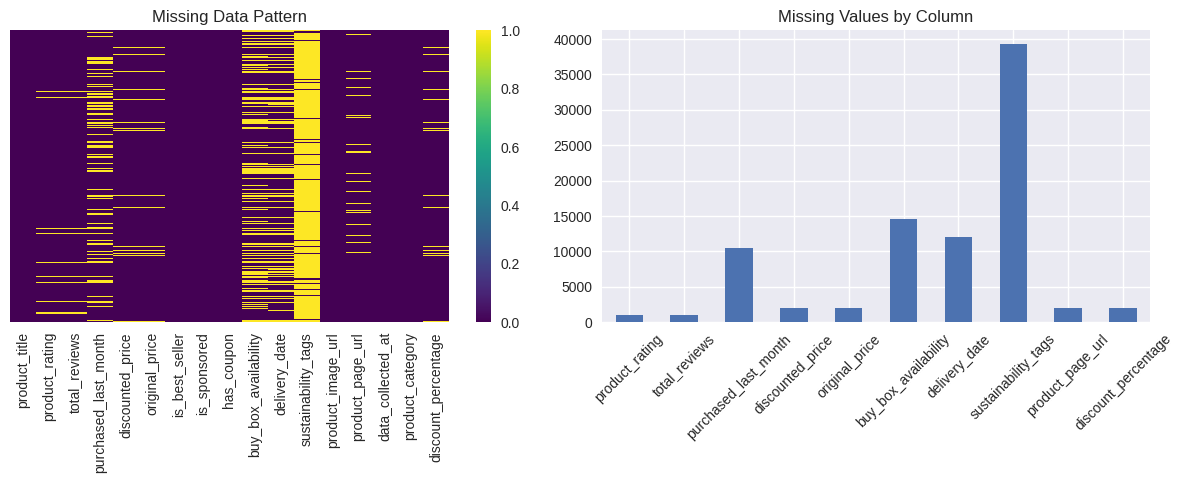

In [ ]:
# Visualize missing data patterns
plt.figure(figsize=(12, 8))

# Missing data heatmap
plt.subplot(2, 2, 1)
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Data Pattern')

# Missing data bar plot
plt.subplot(2, 2, 2)
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]
missing_counts.plot(kind='bar')
plt.title('Missing Values by Column')
plt.xticks(rotation=45)

# Distribution of numerical variables with missing values
  # (john): Which feature will use to show distribution of missing values? sustainablity_tags?



plt.tight_layout()
plt.show()

## Step 2: Handling Missing Values
Different strategies work better for different types of missing data.

2.1 Extract Categories from Product Title


Saving the modified version of the file where category column has been created, so everyone can start from this one.


In [ ]:
from google.colab import drive
import pandas as pd
import re
import os

# Mount Google Drive
drive.mount('/content/drive')

# ⚠️ CORRECT PATH - Use the actual shared folder name
SHARED_FOLDER = '/content/drive/MyDrive/IT 1371 Midterm/'

# Check if the folder exists
if not os.path.exists(SHARED_FOLDER):
    print(f"❌ Folder not found: {SHARED_FOLDER}")
    print("\nAvailable folders in MyDrive:")
    print(os.listdir('/content/drive/MyDrive/'))
else:
    print(f"✅ Found folder: {SHARED_FOLDER}")

# Define the function to extract categories
def extract_category(title):
    """Extract product category from title"""
    if pd.isna(title):
        return 'Unknown'

    title_lower = title.lower()

    categories = {
        'Headphones': ['headphones', 'earbuds', 'airpods', 'earphones'],
        'Laptops': ['macbook', 'laptop', 'chromebook', 'notebook'],
        'Phones': ['iphone', 'phone', 'smartphone'],
        'Tablets': ['ipad', 'tablet'],
        'Watches': ['watch', 'smartwatch'],
        'Cameras': ['camera', 'webcam'],
        'Chargers': ['charger', 'charging', 'power bank', 'battery'],
        'Cables': ['cable', 'cord', 'usb'],
        'Cases': ['case', 'cover', 'protector'],
        'Trackers': ['airtag', 'tracker', 'tile'],
        'Speakers': ['speaker', 'echo', 'alexa'],
        'Storage': ['ssd', 'hard drive', 'storage'],
        'TV & Display': ['tv', 'monitor', 'display', 'screen', 'projector'],
        'Smart Home': ['smart', 'hub', 'home automation'],
        'Audio': ['audio', 'sound', 'microphone'],
        'Other Electronics': []
    }

    for category, keywords in categories.items():
        for keyword in keywords:
            if keyword in title_lower:
                return category

    return 'Other Electronics'

# Load your data (if not already loaded)
if 'df' not in locals():
    # Update this path to where your cleaned data is
    df = pd.read_excel(SHARED_FOLDER + 'amazon_products_sales_data_cleaned.xlsx')
    print(f"✅ Loaded data: {len(df)} rows")

# Apply categorization
df['category'] = df['product_title'].apply(extract_category)

# Quick validation
print("\nCategory Distribution:")
print(df['category'].value_counts())

# Save to the correct shared folder
save_path = SHARED_FOLDER + 'amazon_products_with_categories.xlsx'
df.to_excel(save_path, index=False)
print(f"\n✅ File saved: {save_path}")
print("Your team can now access the categorized data!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Found folder: /content/drive/MyDrive/IT 1371 Midterm/

Category Distribution:
category
Other Electronics    14899
Laptops               4028
Cables                3580
Cameras               3229
Chargers              2961
Phones                2911
Headphones            2788
TV & Display          1880
Speakers              1714
Cases                 1110
Storage                900
Tablets                758
Watches                752
Smart Home             568
Audio                  507
Trackers                90
Name: count, dtype: int64

✅ File saved: /content/drive/MyDrive/IT 1371 Midterm/amazon_products_with_categories.xlsx
Your team can now access the categorized data!


### 2.1 Understanding Missing Data Patterns

In [ ]:
print("="*70)
print("MISSING DATA ANALYSIS - AMAZON PRODUCTS DATASET")
print("="*70)

# ==========================================
# 1. OVERALL MISSING DATA SUMMARY
# ==========================================
print("\n📊 Overall Missing Data Summary:")
missing_summary = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_summary = missing_summary[missing_summary['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)
print(missing_summary)

# ==========================================
# 2. ANALYZE MISSING PATTERNS BY CATEGORY
# ==========================================
print("\n" + "="*70)
print("🔍 MISSING DATA PATTERNS BY PRODUCT CATEGORY")
print("="*70)

# Check purchased_last_month missing pattern by category
print("\n1. Purchased Last Month Missing Pattern:")
purchase_missing = df[df['purchased_last_month'].isnull()]
print(f"   • Total missing: {len(purchase_missing)} ({len(purchase_missing)/len(df)*100:.2f}%)")
print(f"   • Missing by category:")
print(purchase_missing['category'].value_counts())

# Check product_rating missing pattern by category
print("\n2. Product Rating Missing Pattern:")
rating_missing = df[df['product_rating'].isnull()]
print(f"   • Total missing: {len(rating_missing)} ({len(rating_missing)/len(df)*100:.2f}%)")
print(f"   • Missing by category:")
print(rating_missing['category'].value_counts())

# Check if products with no reviews also have no ratings
print("\n3. Correlation between missing reviews and ratings:")
no_reviews = df['total_reviews'].isnull()
no_rating = df['product_rating'].isnull()
both_missing = no_reviews & no_rating
print(f"   • Products missing both reviews AND rating: {both_missing.sum()}")

# ==========================================
# 3. ANALYZE MISSING PATTERNS BY PRICE RANGE
# ==========================================
print("\n" + "="*70)
print("💰 MISSING DATA PATTERNS BY PRICE RANGE")
print("="*70)

# Create price bins (for products with prices)
df_with_price = df[df['original_price'].notna()].copy()
df_with_price['price_range'] = pd.cut(df_with_price['original_price'],
                                       bins=[0, 50, 100, 200, 500, float('inf')],
                                       labels=['$0-50', '$50-100', '$100-200', '$200-500', '$500+'])

print("\nMissing purchased_last_month by price range:")
for price_range in df_with_price['price_range'].unique():
    subset = df_with_price[df_with_price['price_range'] == price_range]
    missing_pct = (subset['purchased_last_month'].isnull().sum() / len(subset) * 100)
    print(f"   • {price_range}: {missing_pct:.1f}% missing")

MISSING DATA ANALYSIS - AMAZON PRODUCTS DATASET

📊 Overall Missing Data Summary:
                                    Column  Missing_Count  Missing_Percentage
sustainability_tags    sustainability_tags          39267               92.01
buy_box_availability  buy_box_availability          14653               34.34
delivery_date                delivery_date          11983               28.08
purchased_last_month  purchased_last_month          10511               24.63
product_page_url          product_page_url           2069                4.85
discounted_price          discounted_price           2062                4.83
original_price              original_price           2062                4.83
discount_percentage    discount_percentage           2062                4.83
total_reviews                total_reviews           1024                2.40
product_rating              product_rating           1024                2.40

🔍 MISSING DATA PATTERNS BY PRODUCT CATEGORY

1. Purchased La

### 2.2 Imputation Strategies

In [ ]:
print("\n" + "="*70)
print("🔧 APPLYING IMPUTATION STRATEGIES")
print("="*70)

# Create a copy for preprocessing
df_processed = df.copy()

# Strategy 1: Fill purchased_last_month with 0 (no purchases)
print("\n✅ Strategy 1: Filling purchased_last_month with 0")
df_processed['purchased_last_month'] = df_processed['purchased_last_month'].fillna(0)
print(f"   Remaining missing: {df_processed['purchased_last_month'].isnull().sum()}")

# Strategy 2: Fill total_reviews with 0 (new products)
print("\n✅ Strategy 2: Filling total_reviews with 0")
df_processed['total_reviews'] = df_processed['total_reviews'].fillna(0)
print(f"   Remaining missing: {df_processed['total_reviews'].isnull().sum()}")

# Strategy 3: Fill product_rating with CATEGORY median (smarter than overall median)
print("\n✅ Strategy 3: Filling product_rating with category median")
category_rating_median = df_processed.groupby('category')['product_rating'].transform(lambda x: x.fillna(x.median()))
df_processed['product_rating'] = category_rating_median

# For categories with ALL missing ratings, use overall median
overall_median = df_processed['product_rating'].median()
df_processed['product_rating'] = df_processed['product_rating'].fillna(overall_median)

print(f"   Remaining missing: {df_processed['product_rating'].isnull().sum()}")
print(f"   Used category-specific medians where available")

# Strategy 4: Fill original_price with category median
print("\n✅ Strategy 4: Filling original_price with category median")
category_price_median = df_processed.groupby('category')['original_price'].transform(lambda x: x.fillna(x.median()))
df_processed['original_price'] = category_price_median

# For categories with ALL missing prices, use overall median
overall_price_median = df_processed['original_price'].median()
df_processed['original_price'] = df_processed['original_price'].fillna(overall_price_median)

print(f"   Remaining missing: {df_processed['original_price'].isnull().sum()}")

# Strategy 5: Fill discounted_price with original_price (no discount)
print("\n✅ Strategy 5: Filling discounted_price with original_price")
df_processed['discounted_price'] = df_processed['discounted_price'].fillna(df_processed['original_price'])
print(f"   Remaining missing: {df_processed['discounted_price'].isnull().sum()}")

# Strategy 6: Fill discount_percentage with 0 (no discount)
print("\n✅ Strategy 6: Filling discount_percentage with 0")
df_processed['discount_percentage'] = df_processed['discount_percentage'].fillna(0)
print(f"   Remaining missing: {df_processed['discount_percentage'].isnull().sum()}")

# Strategy 7: Fill buy_box_availability with 'Unknown'
print("\n✅ Strategy 7: Filling buy_box_availability with 'Unknown'")
df_processed['buy_box_availability'] = df_processed['buy_box_availability'].fillna('Unknown')
print(f"   Remaining missing: {df_processed['buy_box_availability'].isnull().sum()}")

# Strategy 8: Drop columns with >70% missing data
print("\n✅ Strategy 8: Dropping sparse columns (>70% missing)")
columns_to_drop = ['sustainability_tags', 'delivery_date', 'product_page_url']
df_processed = df_processed.drop(columns=columns_to_drop)
print(f"   Dropped: {columns_to_drop}")

# ==========================================
# 5. VERIFICATION
# ==========================================
print("\n" + "="*70)
print("✅ FINAL VERIFICATION")
print("="*70)

print("\nRemaining missing values:")
final_missing = df_processed.isnull().sum()
print(final_missing[final_missing > 0])

if df_processed.isnull().sum().sum() == 0:
    print("\n🎉 SUCCESS! No missing values remain!")
else:
    print(f"\n⚠️ Warning: {df_processed.isnull().sum().sum()} missing values still exist")

print(f"\nFinal dataset shape: {df_processed.shape}")
print(f"Original dataset shape: {df.shape}")

# ==========================================
# 6. SAVE PROCESSED DATA
# ==========================================
save_path = SHARED_FOLDER + 'amazon_products_fully_cleaned.xlsx'
df_processed.to_excel(save_path, index=False)
print(f"\n💾 Saved cleaned data to: {save_path}")


🔧 APPLYING IMPUTATION STRATEGIES

✅ Strategy 1: Filling purchased_last_month with 0
   Remaining missing: 0

✅ Strategy 2: Filling total_reviews with 0
   Remaining missing: 0

✅ Strategy 3: Filling product_rating with category median
   Remaining missing: 0
   Used category-specific medians where available

✅ Strategy 4: Filling original_price with category median
   Remaining missing: 0

✅ Strategy 5: Filling discounted_price with original_price
   Remaining missing: 0

✅ Strategy 6: Filling discount_percentage with 0
   Remaining missing: 0

✅ Strategy 7: Filling buy_box_availability with 'Unknown'
   Remaining missing: 0

✅ Strategy 8: Dropping sparse columns (>70% missing)
   Dropped: ['sustainability_tags', 'delivery_date', 'product_page_url']

✅ FINAL VERIFICATION

Remaining missing values:
Series([], dtype: int64)

🎉 SUCCESS! No missing values remain!

Final dataset shape: (42675, 15)
Original dataset shape: (42675, 18)

💾 Saved cleaned data to: /content/drive/MyDrive/IT 1371 

📊 COMPARING DISTRIBUTIONS BEFORE AND AFTER IMPUTATION

🔍 FEATURE 1: purchased_last_month

📈 Before Imputation:
   Missing values: 10511 (24.63%)
   Mean: 1293.67
   Median: 200.00
   Std Dev: 6318.32

📊 After Imputation:
   Missing values: 0
   Mean: 975.03
   Median: 100.00
   Std Dev: 5513.52


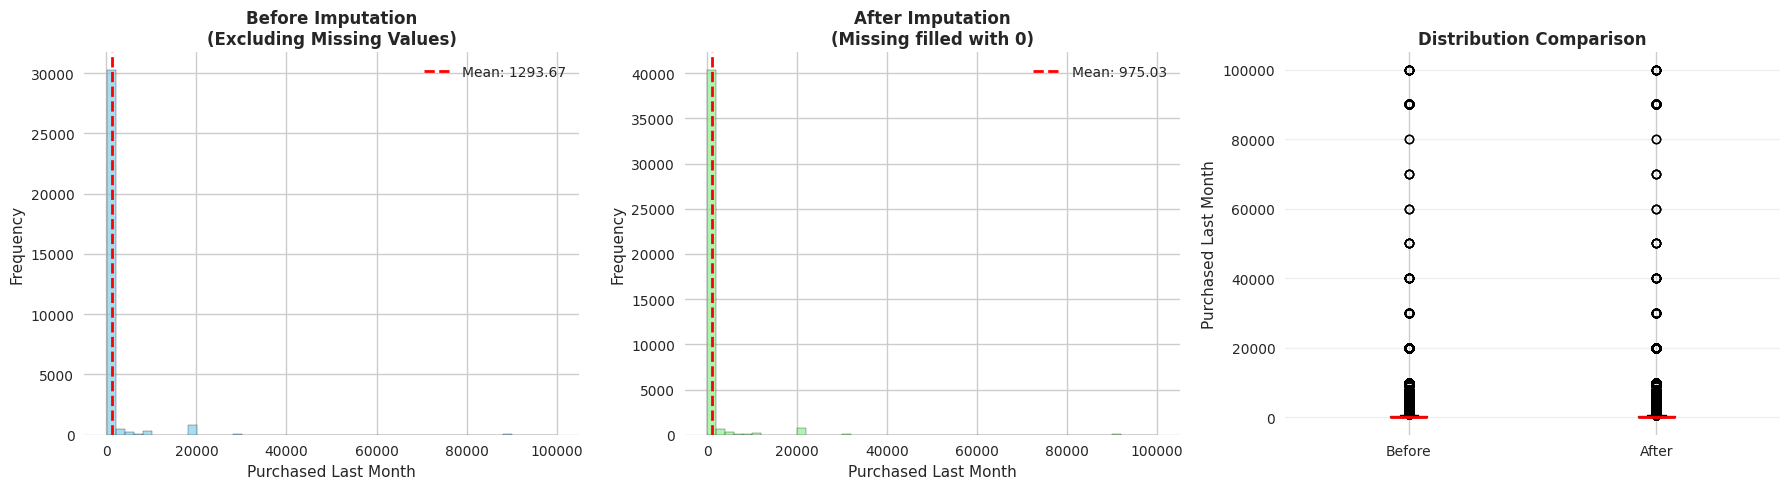


✅ Visualization saved: imputation_comparison_purchased_last_month.png

🔍 FEATURE 2: product_rating

📈 Before Imputation:
   Missing values: 1024 (2.40%)
   Mean: 4.40
   Median: 4.50
   Std Dev: 0.39

📊 After Imputation:
   Missing values: 0
   Mean: 4.40
   Median: 4.50
   Std Dev: 0.38


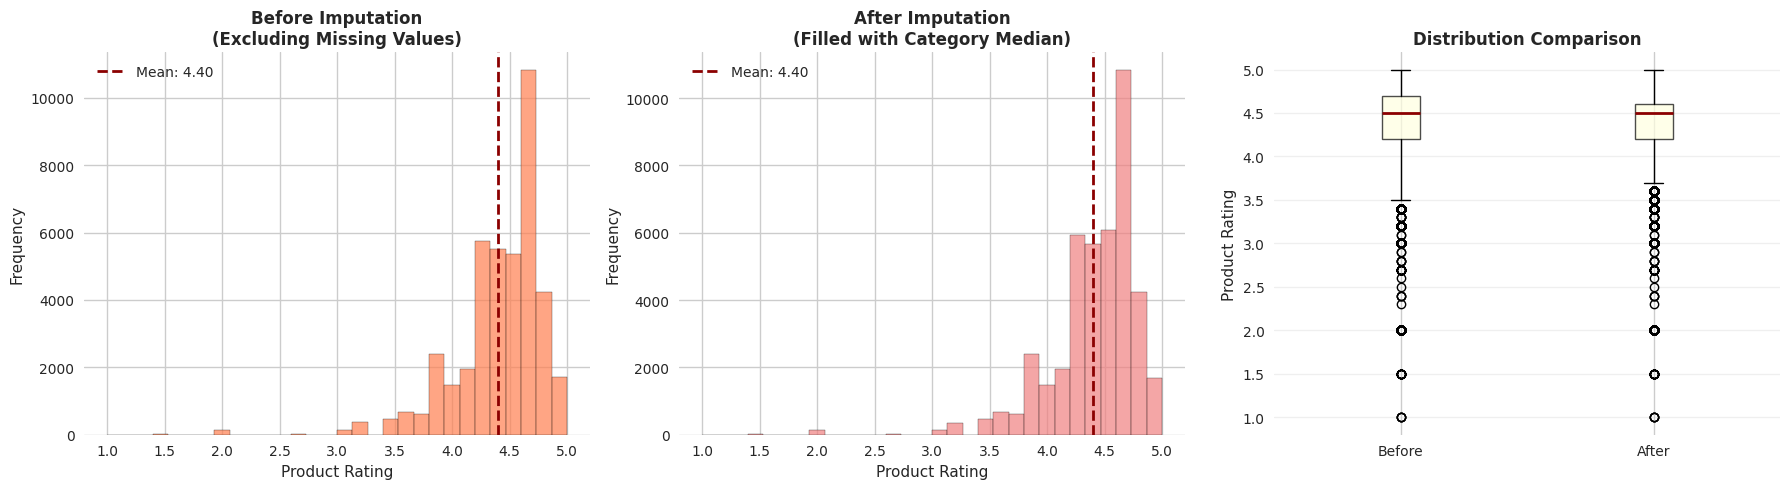


✅ Visualization saved: imputation_comparison_product_rating.png

🔍 FEATURE 3: total_reviews

📈 Before Imputation:
   Missing values: 1024 (2.40%)
   Mean: 3087.11
   Median: 343.00
   Std Dev: 13030.46

📊 After Imputation:
   Missing values: 0
   Mean: 3013.03
   Median: 335.00
   Std Dev: 12881.84


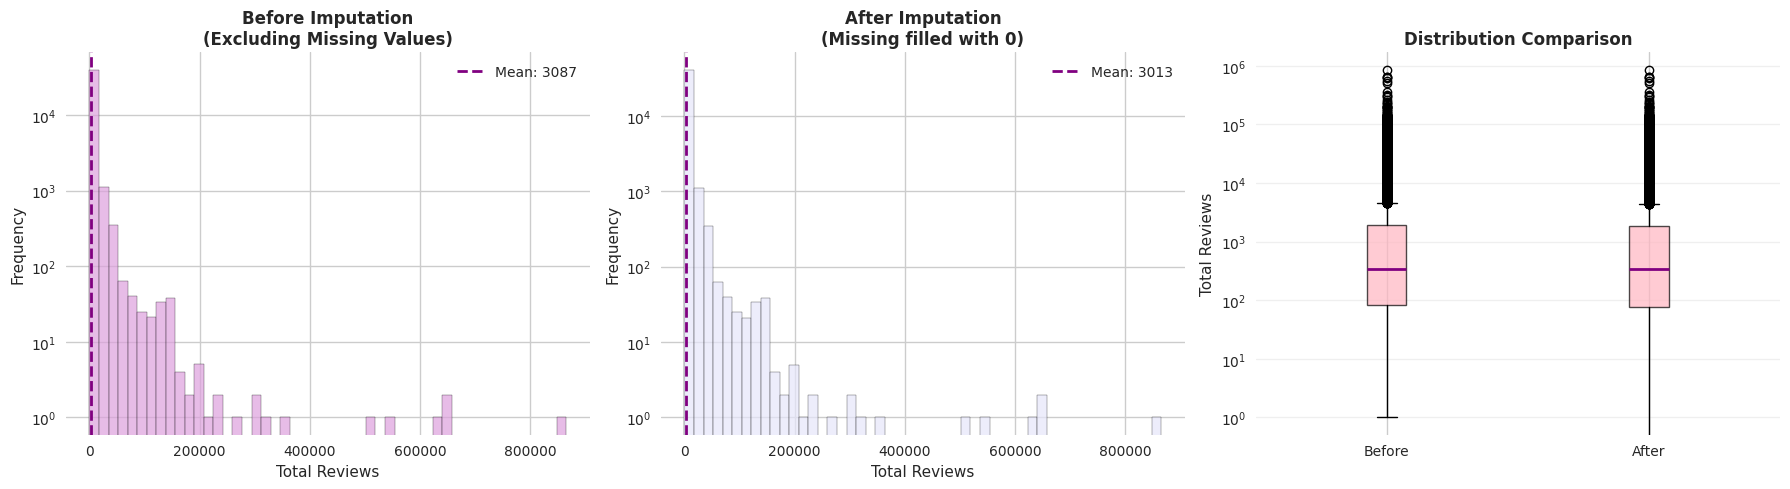


✅ Visualization saved: imputation_comparison_total_reviews.png

🔍 FEATURE 4: original_price

📈 Before Imputation:
   Missing values: 2062 (4.83%)
   Mean: $257.61
   Median: $89.00
   Std Dev: $496.63

📊 After Imputation:
   Missing values: 0
   Mean: $249.43
   Median: $85.99
   Std Dev: $486.07


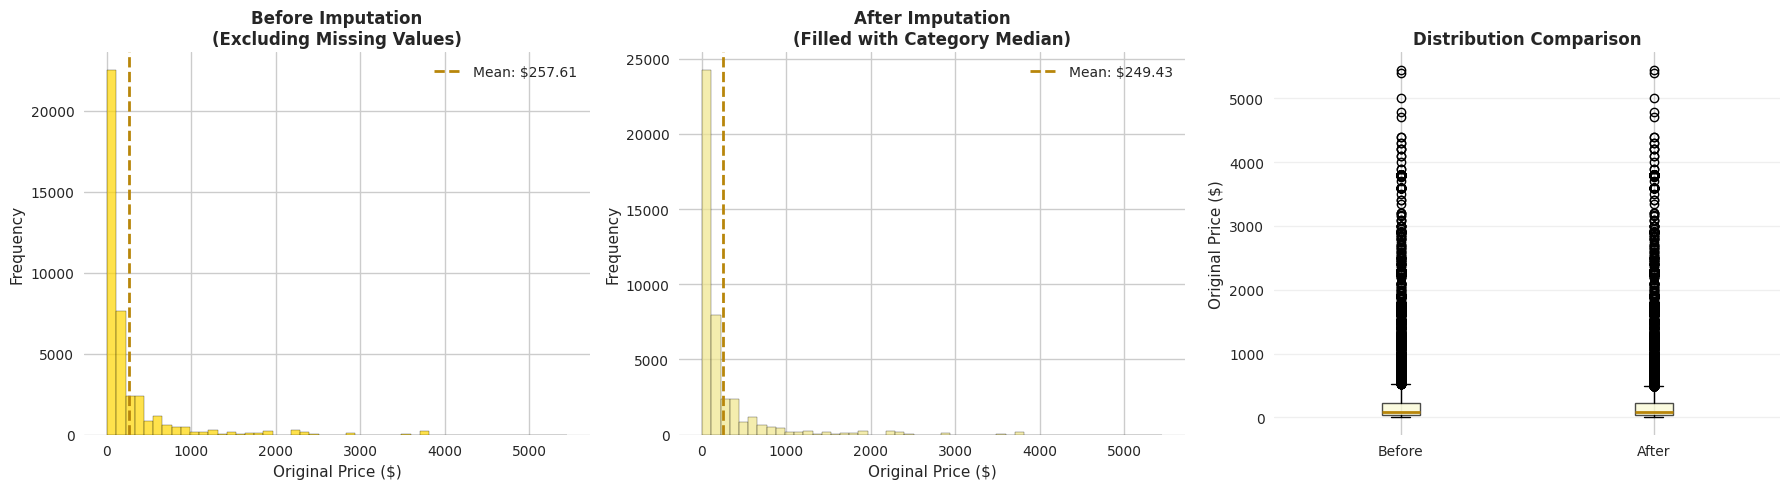


✅ Visualization saved: imputation_comparison_original_price.png

🔍 FEATURE 5: discount_percentage

📈 Before Imputation:
   Missing values: 2062 (4.83%)
   Mean: 6.55%
   Median: 0.00%
   Std Dev: 12.74%

📊 After Imputation:
   Missing values: 0
   Mean: 6.23%
   Median: 0.00%
   Std Dev: 12.51%


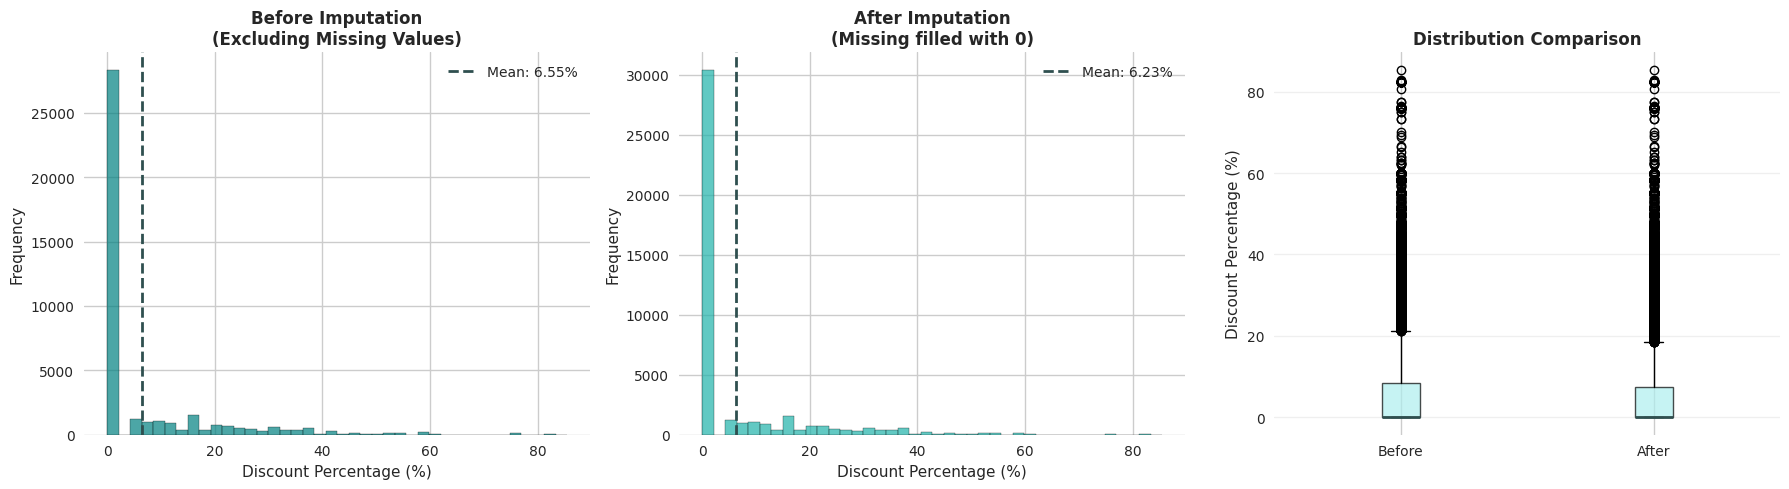


✅ Visualization saved: imputation_comparison_discount_percentage.png

📋 SUMMARY: OVERALL IMPACT OF IMPUTATION

             Feature Missing Before (%) Missing After (%) Mean Before Mean After Mean Change (%)
purchased_last_month             24.63%             0.00%     1293.67     975.03         -24.63%
      product_rating              2.40%             0.00%        4.40       4.40           0.03%
       total_reviews              2.40%             0.00%     3087.11    3013.03          -2.40%
      original_price              4.83%             0.00%      257.61     249.43          -3.18%
 discount_percentage              4.83%             0.00%        6.55       6.23          -4.83%

📊 OVERALL MISSING DATA COMPARISON

Total missing values before: 86717 (11.29% of all data)
Total missing values after: 0 (0.00% of all data)
Missing values resolved: 86717


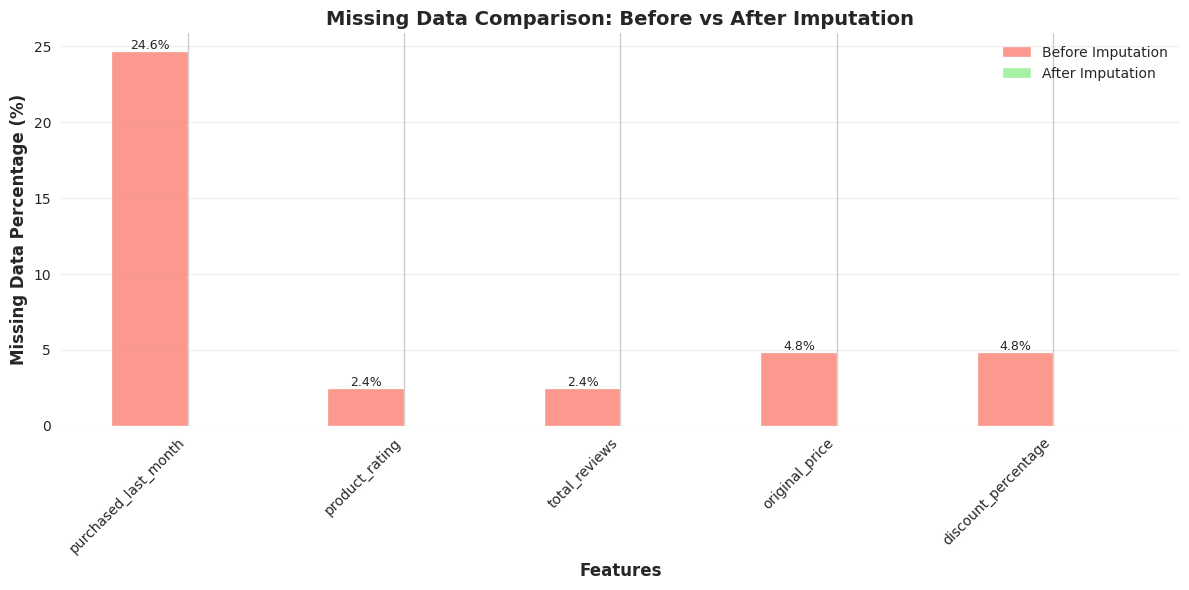


✅ Summary visualization saved: imputation_summary_comparison.png

✅ COMPARISON ANALYSIS COMPLETE!

📁 All visualizations saved to: /content/drive/MyDrive/IT 1371 Midterm/
📊 Generated files:
   1. imputation_comparison_purchased_last_month.png
   2. imputation_comparison_product_rating.png
   3. imputation_comparison_total_reviews.png
   4. imputation_comparison_original_price.png
   5. imputation_comparison_discount_percentage.png
   6. imputation_summary_comparison.png


In [ ]:
# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 6)

print("="*70)
print("📊 COMPARING DISTRIBUTIONS BEFORE AND AFTER IMPUTATION")
print("="*70)

# ==========================================
# SETUP: Save original data before imputation
# ==========================================

# Load the original data
# df_original = pd.read_excel(SHARED_FOLDER + 'amazon_products_with_categories.xlsx')

# Save a copy before imputation
df_original = df.copy()

# ==========================================
# FEATURE 1: purchased_last_month
# ==========================================
print("\n" + "="*70)
print("🔍 FEATURE 1: purchased_last_month")
print("="*70)

# Statistics before imputation
print("\n📈 Before Imputation:")
print(f"   Missing values: {df_original['purchased_last_month'].isnull().sum()} ({df_original['purchased_last_month'].isnull().sum()/len(df_original)*100:.2f}%)")
print(f"   Mean: {df_original['purchased_last_month'].mean():.2f}")
print(f"   Median: {df_original['purchased_last_month'].median():.2f}")
print(f"   Std Dev: {df_original['purchased_last_month'].std():.2f}")

# Statistics after imputation
print("\n📊 After Imputation:")
print(f"   Missing values: {df_processed['purchased_last_month'].isnull().sum()}")
print(f"   Mean: {df_processed['purchased_last_month'].mean():.2f}")
print(f"   Median: {df_processed['purchased_last_month'].median():.2f}")
print(f"   Std Dev: {df_processed['purchased_last_month'].std():.2f}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram - Before
axes[0].hist(df_original['purchased_last_month'].dropna(), bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Before Imputation\n(Excluding Missing Values)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Purchased Last Month')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df_original['purchased_last_month'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df_original["purchased_last_month"].mean():.2f}')
axes[0].legend()

# Histogram - After
axes[1].hist(df_processed['purchased_last_month'], bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1].set_title('After Imputation\n(Missing filled with 0)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Purchased Last Month')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df_processed['purchased_last_month'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df_processed["purchased_last_month"].mean():.2f}')
axes[1].legend()

# Box plot comparison
data_to_plot = [df_original['purchased_last_month'].dropna(), df_processed['purchased_last_month']]
axes[2].boxplot(data_to_plot, labels=['Before', 'After'], patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
axes[2].set_title('Distribution Comparison', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Purchased Last Month')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(SHARED_FOLDER + 'imputation_comparison_purchased_last_month.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Visualization saved: imputation_comparison_purchased_last_month.png")

# ==========================================
# FEATURE 2: product_rating
# ==========================================
print("\n" + "="*70)
print("🔍 FEATURE 2: product_rating")
print("="*70)

# Statistics before imputation
print("\n📈 Before Imputation:")
print(f"   Missing values: {df_original['product_rating'].isnull().sum()} ({df_original['product_rating'].isnull().sum()/len(df_original)*100:.2f}%)")
print(f"   Mean: {df_original['product_rating'].mean():.2f}")
print(f"   Median: {df_original['product_rating'].median():.2f}")
print(f"   Std Dev: {df_original['product_rating'].std():.2f}")

# Statistics after imputation
print("\n📊 After Imputation:")
print(f"   Missing values: {df_processed['product_rating'].isnull().sum()}")
print(f"   Mean: {df_processed['product_rating'].mean():.2f}")
print(f"   Median: {df_processed['product_rating'].median():.2f}")
print(f"   Std Dev: {df_processed['product_rating'].std():.2f}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram - Before
axes[0].hist(df_original['product_rating'].dropna(), bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[0].set_title('Before Imputation\n(Excluding Missing Values)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Product Rating')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df_original['product_rating'].mean(), color='darkred', linestyle='--', linewidth=2, label=f'Mean: {df_original["product_rating"].mean():.2f}')
axes[0].legend()

# Histogram - After
axes[1].hist(df_processed['product_rating'], bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
axes[1].set_title('After Imputation\n(Filled with Category Median)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Product Rating')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df_processed['product_rating'].mean(), color='darkred', linestyle='--', linewidth=2, label=f'Mean: {df_processed["product_rating"].mean():.2f}')
axes[1].legend()

# Box plot comparison
data_to_plot = [df_original['product_rating'].dropna(), df_processed['product_rating']]
axes[2].boxplot(data_to_plot, labels=['Before', 'After'], patch_artist=True,
                boxprops=dict(facecolor='lightyellow', alpha=0.7),
                medianprops=dict(color='darkred', linewidth=2))
axes[2].set_title('Distribution Comparison', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Product Rating')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(SHARED_FOLDER + 'imputation_comparison_product_rating.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Visualization saved: imputation_comparison_product_rating.png")

# ==========================================
# FEATURE 3: total_reviews
# ==========================================
print("\n" + "="*70)
print("🔍 FEATURE 3: total_reviews")
print("="*70)

# Statistics before imputation
print("\n📈 Before Imputation:")
print(f"   Missing values: {df_original['total_reviews'].isnull().sum()} ({df_original['total_reviews'].isnull().sum()/len(df_original)*100:.2f}%)")
print(f"   Mean: {df_original['total_reviews'].mean():.2f}")
print(f"   Median: {df_original['total_reviews'].median():.2f}")
print(f"   Std Dev: {df_original['total_reviews'].std():.2f}")

# Statistics after imputation
print("\n📊 After Imputation:")
print(f"   Missing values: {df_processed['total_reviews'].isnull().sum()}")
print(f"   Mean: {df_processed['total_reviews'].mean():.2f}")
print(f"   Median: {df_processed['total_reviews'].median():.2f}")
print(f"   Std Dev: {df_processed['total_reviews'].std():.2f}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram - Before (log scale for better visualization)
axes[0].hist(df_original['total_reviews'].dropna(), bins=50, color='plum', edgecolor='black', alpha=0.7)
axes[0].set_title('Before Imputation\n(Excluding Missing Values)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Total Reviews')
axes[0].set_ylabel('Frequency')
axes[0].set_yscale('log')
axes[0].axvline(df_original['total_reviews'].mean(), color='purple', linestyle='--', linewidth=2, label=f'Mean: {df_original["total_reviews"].mean():.0f}')
axes[0].legend()

# Histogram - After
axes[1].hist(df_processed['total_reviews'], bins=50, color='lavender', edgecolor='black', alpha=0.7)
axes[1].set_title('After Imputation\n(Missing filled with 0)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Total Reviews')
axes[1].set_ylabel('Frequency')
axes[1].set_yscale('log')
axes[1].axvline(df_processed['total_reviews'].mean(), color='purple', linestyle='--', linewidth=2, label=f'Mean: {df_processed["total_reviews"].mean():.0f}')
axes[1].legend()

# Box plot comparison
data_to_plot = [df_original['total_reviews'].dropna(), df_processed['total_reviews']]
axes[2].boxplot(data_to_plot, labels=['Before', 'After'], patch_artist=True,
                boxprops=dict(facecolor='lightpink', alpha=0.7),
                medianprops=dict(color='purple', linewidth=2))
axes[2].set_title('Distribution Comparison', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Total Reviews')
axes[2].set_yscale('log')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(SHARED_FOLDER + 'imputation_comparison_total_reviews.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Visualization saved: imputation_comparison_total_reviews.png")

# ==========================================
# FEATURE 4: original_price
# ==========================================
print("\n" + "="*70)
print("🔍 FEATURE 4: original_price")
print("="*70)

# Statistics before imputation
print("\n📈 Before Imputation:")
print(f"   Missing values: {df_original['original_price'].isnull().sum()} ({df_original['original_price'].isnull().sum()/len(df_original)*100:.2f}%)")
print(f"   Mean: ${df_original['original_price'].mean():.2f}")
print(f"   Median: ${df_original['original_price'].median():.2f}")
print(f"   Std Dev: ${df_original['original_price'].std():.2f}")

# Statistics after imputation
print("\n📊 After Imputation:")
print(f"   Missing values: {df_processed['original_price'].isnull().sum()}")
print(f"   Mean: ${df_processed['original_price'].mean():.2f}")
print(f"   Median: ${df_processed['original_price'].median():.2f}")
print(f"   Std Dev: ${df_processed['original_price'].std():.2f}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram - Before
axes[0].hist(df_original['original_price'].dropna(), bins=50, color='gold', edgecolor='black', alpha=0.7)
axes[0].set_title('Before Imputation\n(Excluding Missing Values)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Original Price ($)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df_original['original_price'].mean(), color='darkgoldenrod', linestyle='--', linewidth=2, label=f'Mean: ${df_original["original_price"].mean():.2f}')
axes[0].legend()

# Histogram - After
axes[1].hist(df_processed['original_price'], bins=50, color='khaki', edgecolor='black', alpha=0.7)
axes[1].set_title('After Imputation\n(Filled with Category Median)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Original Price ($)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df_processed['original_price'].mean(), color='darkgoldenrod', linestyle='--', linewidth=2, label=f'Mean: ${df_processed["original_price"].mean():.2f}')
axes[1].legend()

# Box plot comparison
data_to_plot = [df_original['original_price'].dropna(), df_processed['original_price']]
axes[2].boxplot(data_to_plot, labels=['Before', 'After'], patch_artist=True,
                boxprops=dict(facecolor='lightgoldenrodyellow', alpha=0.7),
                medianprops=dict(color='darkgoldenrod', linewidth=2))
axes[2].set_title('Distribution Comparison', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Original Price ($)')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(SHARED_FOLDER + 'imputation_comparison_original_price.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Visualization saved: imputation_comparison_original_price.png")

# ==========================================
# FEATURE 5: discount_percentage
# ==========================================
print("\n" + "="*70)
print("🔍 FEATURE 5: discount_percentage")
print("="*70)

# Statistics before imputation
print("\n📈 Before Imputation:")
print(f"   Missing values: {df_original['discount_percentage'].isnull().sum()} ({df_original['discount_percentage'].isnull().sum()/len(df_original)*100:.2f}%)")
print(f"   Mean: {df_original['discount_percentage'].mean():.2f}%")
print(f"   Median: {df_original['discount_percentage'].median():.2f}%")
print(f"   Std Dev: {df_original['discount_percentage'].std():.2f}%")

# Statistics after imputation
print("\n📊 After Imputation:")
print(f"   Missing values: {df_processed['discount_percentage'].isnull().sum()}")
print(f"   Mean: {df_processed['discount_percentage'].mean():.2f}%")
print(f"   Median: {df_processed['discount_percentage'].median():.2f}%")
print(f"   Std Dev: {df_processed['discount_percentage'].std():.2f}%")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram - Before
axes[0].hist(df_original['discount_percentage'].dropna(), bins=40, color='teal', edgecolor='black', alpha=0.7)
axes[0].set_title('Before Imputation\n(Excluding Missing Values)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Discount Percentage (%)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df_original['discount_percentage'].mean(), color='darkslategray', linestyle='--', linewidth=2, label=f'Mean: {df_original["discount_percentage"].mean():.2f}%')
axes[0].legend()

# Histogram - After
axes[1].hist(df_processed['discount_percentage'], bins=40, color='lightseagreen', edgecolor='black', alpha=0.7)
axes[1].set_title('After Imputation\n(Missing filled with 0)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Discount Percentage (%)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df_processed['discount_percentage'].mean(), color='darkslategray', linestyle='--', linewidth=2, label=f'Mean: {df_processed["discount_percentage"].mean():.2f}%')
axes[1].legend()

# Box plot comparison
data_to_plot = [df_original['discount_percentage'].dropna(), df_processed['discount_percentage']]
axes[2].boxplot(data_to_plot, labels=['Before', 'After'], patch_artist=True,
                boxprops=dict(facecolor='paleturquoise', alpha=0.7),
                medianprops=dict(color='darkslategray', linewidth=2))
axes[2].set_title('Distribution Comparison', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Discount Percentage (%)')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(SHARED_FOLDER + 'imputation_comparison_discount_percentage.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Visualization saved: imputation_comparison_discount_percentage.png")

# ==========================================
# SUMMARY: Overall Impact of Imputation
# ==========================================
print("\n" + "="*70)
print("📋 SUMMARY: OVERALL IMPACT OF IMPUTATION")
print("="*70)

# Create summary table
summary_data = {
    'Feature': [],
    'Missing Before (%)': [],
    'Missing After (%)': [],
    'Mean Before': [],
    'Mean After': [],
    'Mean Change (%)': []
}

features_to_summarize = ['purchased_last_month', 'product_rating', 'total_reviews',
                         'original_price', 'discount_percentage']

for feature in features_to_summarize:
    if feature in df_original.columns and feature in df_processed.columns:
        missing_before = df_original[feature].isnull().sum() / len(df_original) * 100
        missing_after = df_processed[feature].isnull().sum() / len(df_processed) * 100
        mean_before = df_original[feature].mean()
        mean_after = df_processed[feature].mean()
        mean_change = ((mean_after - mean_before) / mean_before * 100) if mean_before != 0 else 0

        summary_data['Feature'].append(feature)
        summary_data['Missing Before (%)'].append(f"{missing_before:.2f}%")
        summary_data['Missing After (%)'].append(f"{missing_after:.2f}%")
        summary_data['Mean Before'].append(f"{mean_before:.2f}")
        summary_data['Mean After'].append(f"{mean_after:.2f}")
        summary_data['Mean Change (%)'].append(f"{mean_change:.2f}%")

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

# Overall missing data comparison
print("\n" + "="*70)
print("📊 OVERALL MISSING DATA COMPARISON")
print("="*70)

total_missing_before = df_original.isnull().sum().sum()
total_missing_after = df_processed.isnull().sum().sum()
total_cells = df_original.shape[0] * df_original.shape[1]

print(f"\nTotal missing values before: {total_missing_before} ({total_missing_before/total_cells*100:.2f}% of all data)")
print(f"Total missing values after: {total_missing_after} ({total_missing_after/total_cells*100:.2f}% of all data)")
print(f"Missing values resolved: {total_missing_before - total_missing_after}")

# Create final comparison visualization
fig, ax = plt.subplots(figsize=(12, 6))

features = summary_data['Feature']
missing_before = [float(x.strip('%')) for x in summary_data['Missing Before (%)']]
missing_after = [float(x.strip('%')) for x in summary_data['Missing After (%)']]

x = np.arange(len(features))
width = 0.35

bars1 = ax.bar(x - width/2, missing_before, width, label='Before Imputation', color='salmon', alpha=0.8)
bars2 = ax.bar(x + width/2, missing_after, width, label='After Imputation', color='lightgreen', alpha=0.8)

ax.set_xlabel('Features', fontsize=12, fontweight='bold')
ax.set_ylabel('Missing Data Percentage (%)', fontsize=12, fontweight='bold')
ax.set_title('Missing Data Comparison: Before vs After Imputation', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(features, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.1f}%',
                   ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(SHARED_FOLDER + 'imputation_summary_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Summary visualization saved: imputation_summary_comparison.png")

print("\n" + "="*70)
print("✅ COMPARISON ANALYSIS COMPLETE!")
print("="*70)
print(f"\n📁 All visualizations saved to: {SHARED_FOLDER}")
print("📊 Generated files:")
print("   1. imputation_comparison_purchased_last_month.png")
print("   2. imputation_comparison_product_rating.png")
print("   3. imputation_comparison_total_reviews.png")
print("   4. imputation_comparison_original_price.png")
print("   5. imputation_comparison_discount_percentage.png")
print("   6. imputation_summary_comparison.png")

## Step 3: Encoding Categorical Variables
Machine learning algorithms work with numbers, so we need to convert categorical data.

In [ ]:
# Identify categorical columns
categorical_columns = ['category','is_best_seller', 'has_coupon','is_sponsored']
print("Categorical columns to encode:")
for col in categorical_columns:
    print(f"• {col}: {df_processed[col].nunique()} unique values")
    print(f"  Values: {list(df_processed[col].unique())}")
    print()


Categorical columns to encode:
• category: 16 unique values
  Values: ['Phones', 'Laptops', 'Headphones', 'Other Electronics', 'Cases', 'Tablets', 'Storage', 'Cameras', 'TV & Display', 'Chargers', 'Watches', 'Cables', 'Speakers', 'Audio', 'Trackers', 'Smart Home']

• is_best_seller: 12 unique values
  Values: ['No Badge', 'Best Seller', "Amazon's", 'Limited time deal', 'Save 30%', 'Save 12%', 'Save 9%', 'Save 17%', 'Save 77%', 'Ends in', 'Save 10%', 'Save 18%']

• has_coupon: 42 unique values
  Values: ['Save 15%  with coupon', 'No Coupon', 'Save 50%  with coupon', 'Save $16.00  with coupon', 'Save $10.00  with coupon', 'Save 10%  with coupon', 'Save $20.00  with coupon', 'Save $4.00  with coupon', 'Save $0.33  with coupon', 'Save $18.00  with coupon', 'Save 5%  with coupon', 'Save $2.00  with coupon', 'Save $15.00  with coupon', 'Save 6%  with coupon', 'Save $8.00  with coupon', 'Save $40.00  with coupon', 'Save $1.50  with coupon', 'Save 7%  with coupon', 'Save 20%  with coupon', 'Sa

### 3.1 Ordinal Encoding (for ordered categories)


Ordinal Encoding Applied:

Badge Mapping:
  No Badge → 0
  Has Badge → 1

Badge counts:
badge_clean
No Badge     40814
Has Badge     1861
Name: count, dtype: int64
Share with badge: 0.04360867018160516


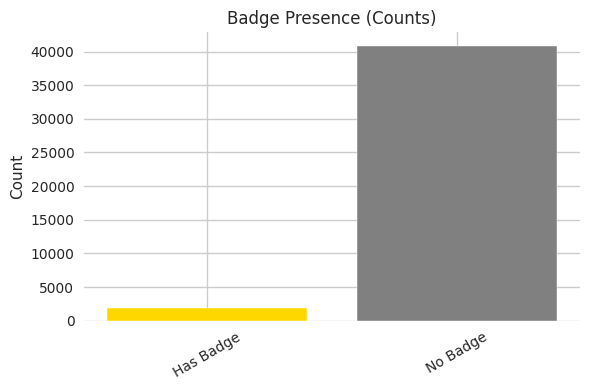


Coupon Mapping:
  No Coupon → 0
  Has Coupon → 1

Coupon counts:
coupon_clean
No Coupon     40727
Has Coupon     1948
Name: count, dtype: int64


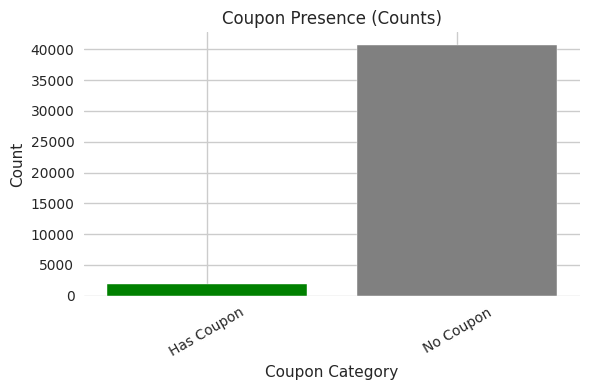


Buy Box Availability Mapping:
  Unknown/Unavailable → 0
  Available → 1

Buy Box Availability counts:
buy_box_clean
Available              28022
Unknown/Unavailable    14653
Name: count, dtype: int64


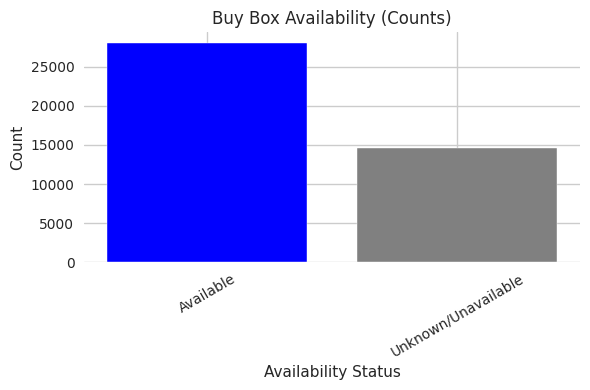

In [ ]:
# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)


# Encode for is_best_seller
print("Ordinal Encoding Applied:")

# Make a clean binary label
df_processed['badge_clean'] = np.where(
    df_processed['is_best_seller'].fillna('').str.contains('No Badge', case=False),
    'No Badge',
    'Has Badge'
)

# Define mapping (ordinal)
badge_mapping = {'No Badge': 0, 'Has Badge': 1}
df_processed['badge_encoded'] = df_processed['badge_clean'].map(badge_mapping)

print("\nBadge Mapping:")
for original, encoded in badge_mapping.items():
    print(f"  {original} → {encoded}")


print("\nBadge counts:")
print(df_processed['badge_clean'].value_counts())
print('Share with badge:', df_processed['badge_encoded'].mean())

# Viz for Badge encoding
counts = df_processed['badge_clean'].value_counts().reindex(['Has Badge','No Badge'], fill_value=0)

fig, ax = plt.subplots(figsize=(6,4))
ax.bar(counts.index, counts.values, color=['gold','gray'])
ax.set_title('Badge Presence (Counts)')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


# Encode has_coupon
# Create a simplified coupon column (binary category)
df_processed['coupon_clean'] = np.where(
    df_processed['has_coupon'].fillna('').str.contains('No Coupon', case=False),
    'No Coupon',
    'Has Coupon'
)

# Define mapping (ordinal)
coupon_mapping = {'No Coupon': 0, 'Has Coupon': 1}
df_processed['coupon_encoded'] = df_processed['coupon_clean'].map(coupon_mapping)

# Verify encoding
print("\nCoupon Mapping:")
for original, encoded in coupon_mapping.items():
    print(f"  {original} → {encoded}")

print("\nCoupon counts:")
print(df_processed['coupon_clean'].value_counts())

# Viz for coupon encoding
coupon_counts = df_processed['coupon_clean'].value_counts().reindex(['Has Coupon', 'No Coupon'], fill_value=0)

plt.figure(figsize=(6,4))
plt.bar(coupon_counts.index, coupon_counts.values, color=['green', 'gray'])
plt.title('Coupon Presence (Counts)')
plt.ylabel('Count')
plt.xlabel('Coupon Category')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# Encode buy_box_availability
# Create a simplified buy_box_availability column (binary category)
df_processed['buy_box_clean'] = np.where(
    df_processed['buy_box_availability'].fillna('').str.contains('Add to cart', case=False),
    'Available',
    'Unknown/Unavailable'
)

# Define mapping (ordinal)
buy_box_mapping = {'Unknown/Unavailable': 0, 'Available': 1}
df_processed['buy_box_encoded'] = df_processed['buy_box_clean'].map(buy_box_mapping)

# Verify encoding
print("\nBuy Box Availability Mapping:")
for original, encoded in buy_box_mapping.items():
    print(f"  {original} → {encoded}")

print("\nBuy Box Availability counts:")
print(df_processed['buy_box_clean'].value_counts())

# Viz for buy box encoding
buy_box_counts = df_processed['buy_box_clean'].value_counts().reindex(['Available', 'Unknown/Unavailable'], fill_value=0)

plt.figure(figsize=(6,4))
plt.bar(buy_box_counts.index, buy_box_counts.values, color=['blue', 'gray'])
plt.title('Buy Box Availability (Counts)')
plt.ylabel('Count')
plt.xlabel('Availability Status')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 3.2 One-Hot Encoding (for nominal categories)

In [ ]:
# Features that don't have natural order - use one-hot encoding

#Doing Category column
# Create dummy variables
prod_catagory_dummies = pd.get_dummies(df_processed['category'], prefix='cat')

print("One-Hot Encoding Applied:")
print(f"\nProduct Category columns created: {list(prod_catagory_dummies.columns)}")


# Add to dataframe
df_processed = pd.concat([df_processed, prod_catagory_dummies], axis=1)

print(f"\nDataset shape after encoding: {df_processed.shape}")


# Doing Sponsored column
# Create dummy variables
sponsored_dummies = pd.get_dummies(df_processed['is_sponsored'], prefix='sponsored')

print("One-Hot Encoding Applied:")
print(f"\nSponsored columns created: {list(sponsored_dummies.columns)}")

# Add to dataframe
df_processed = pd.concat([df_processed, sponsored_dummies], axis=1)

print(f"\nDataset shape after encoding: {df_processed.shape}")



One-Hot Encoding Applied:

Product Category columns created: ['cat_Audio', 'cat_Cables', 'cat_Cameras', 'cat_Cases', 'cat_Chargers', 'cat_Headphones', 'cat_Laptops', 'cat_Other Electronics', 'cat_Phones', 'cat_Smart Home', 'cat_Speakers', 'cat_Storage', 'cat_TV & Display', 'cat_Tablets', 'cat_Trackers', 'cat_Watches']

Dataset shape after encoding: (42675, 37)
One-Hot Encoding Applied:

Sponsored columns created: ['sponsored_Organic', 'sponsored_Sponsored']

Dataset shape after encoding: (42675, 39)


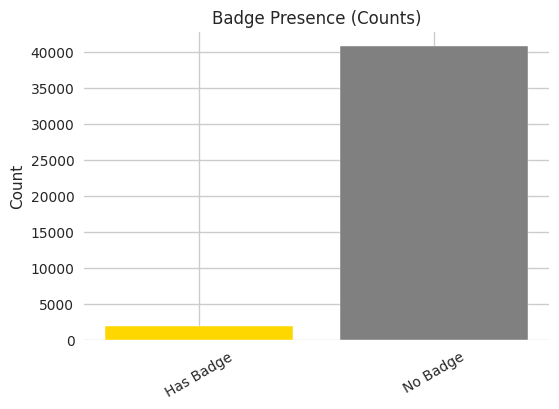

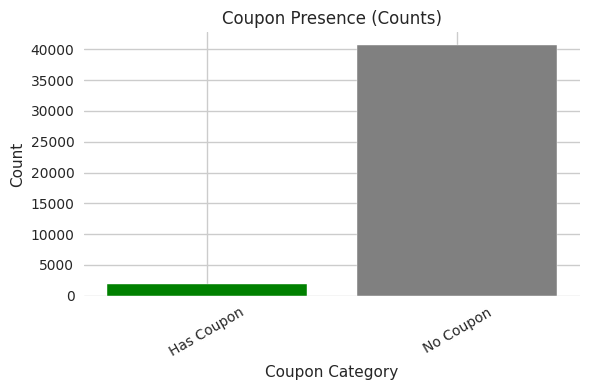

In [ ]:
# Viz for Ordinal encoding

# Badge Encoding visualization
counts = df_processed['badge_clean'].value_counts().reindex(['Has Badge','No Badge'], fill_value=0)

fig, ax = plt.subplots(figsize=(6,4))
ax.bar(counts.index, counts.values, color=['gold','gray'])
ax.set_title('Badge Presence (Counts)')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)



# Count plot
coupon_counts = df_processed['coupon_clean'].value_counts().reindex(['Has Coupon', 'No Coupon'], fill_value=0)

plt.figure(figsize=(6,4))
plt.bar(coupon_counts.index, coupon_counts.values, color=['green', 'gray'])
plt.title('Coupon Presence (Counts)')
plt.ylabel('Count')
plt.xlabel('Coupon Category')
plt.xticks(rotation=30)


plt.tight_layout()
plt.show()

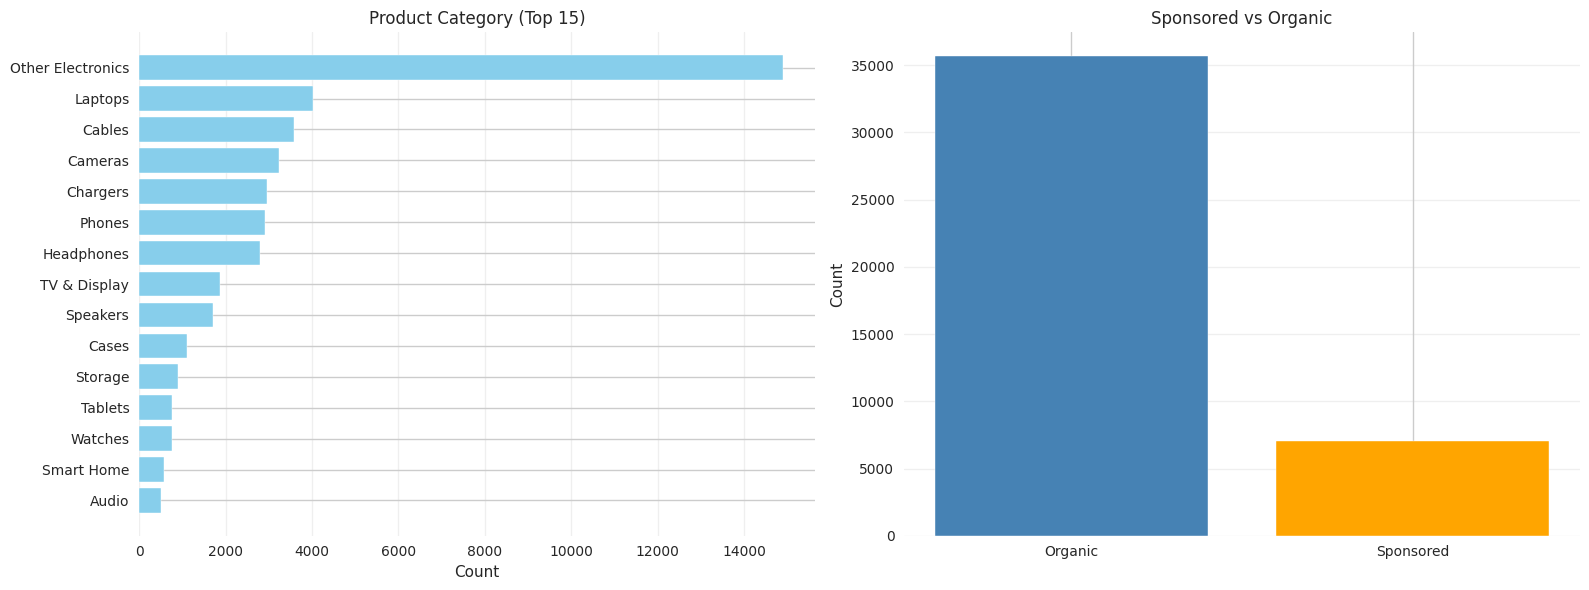

In [ ]:
# Visualize the encoding results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Category counts (use the original categorical column)
top_n = 15
cat_counts = df_processed['category'].value_counts().head(top_n).sort_values(ascending=True)
axes[0].barh(cat_counts.index, cat_counts.values, color='skyblue')
axes[0].set_title(f'Product Category (Top {top_n})')
axes[0].set_xlabel('Count')
axes[0].grid(True, axis='x', alpha=0.3)

# Sponsored counts (use the original column you one-hot encoded from)
sponsored_counts = (
    df_processed['is_sponsored']
      .replace({'Sponsored':'Sponsored', 'Organic':'Organic'})
      .value_counts()
      .reindex(['Organic','Sponsored'], fill_value=0)
)
axes[1].bar(sponsored_counts.index, sponsored_counts.values, color=['steelblue','orange'])
axes[1].set_title('Sponsored vs Organic')
axes[1].set_ylabel('Count')
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## Step 4: Feature Scaling and Normalization
Different features have different scales, which can bias machine learning algorithms.

In [ ]:
# Identify numerical columns for scaling
numerical_columns = ['purchased_last_month', 'product_rating', 'total_reviews',
                     'original_price', 'discount_percentage']

print("Numerical columns to scale:")
print(df_processed[numerical_columns].describe().round(2))

Numerical columns to scale:
       purchased_last_month  product_rating  total_reviews  original_price  \
count              42675.00        42675.00       42675.00        42675.00   
mean                 975.03            4.40        3013.03          249.43   
std                 5513.52            0.38       12881.84          486.07   
min                    0.00            1.00           0.00            2.16   
25%                   50.00            4.20          75.00           33.90   
50%                  100.00            4.50         335.00           85.99   
75%                  300.00            4.60        1825.50          219.00   
max               100000.00            5.00      865598.00         5449.00   

       discount_percentage  
count             42675.00  
mean                  6.23  
std                  12.51  
min                   0.00  
25%                   0.00  
50%                   0.00  
75%                   7.41  
max                  85.42  


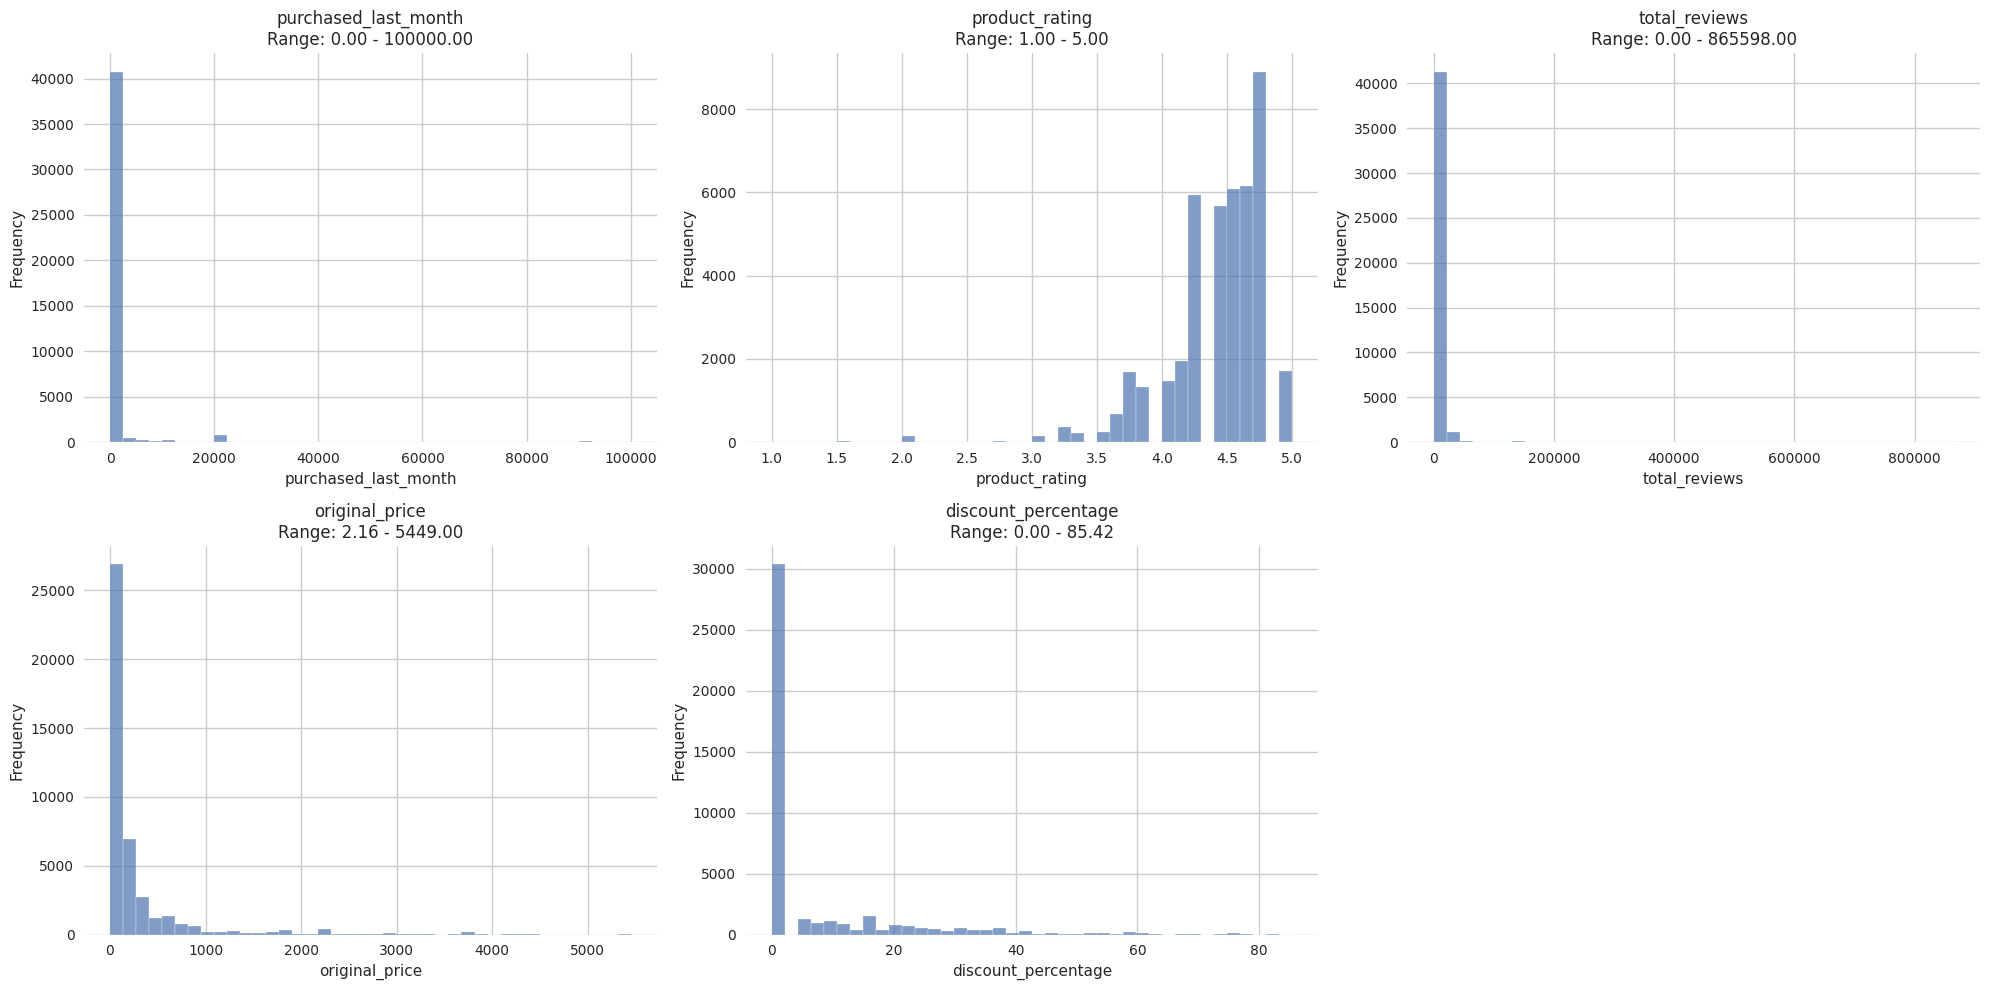

In [ ]:
# Visualize the scale differences
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.ravel()

for i, col in enumerate(numerical_columns):
  axes[i].hist(df_processed[col], bins=40, alpha=0.7)
  axes[i].set_title(f'{col}\nRange: {df_processed[col].min():.2f} - {df_processed[col].max():.2f}')
  axes[i].set_xlabel(col)
  axes[i].set_ylabel('Frequency')

# Remove empty subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

### 4.1 Standard Scaling (Z-score normalization)

In [ ]:
# Apply StandardScaler (mean=0, std=1)
scaler_standard = StandardScaler()

# Exclude our target variable from scaling:Purchased Last Month
features_to_scale = [col for col in numerical_columns if col != 'purchased_last_month']

# Fit and transform
df_standard_scaled = df_processed.copy()
df_standard_scaled[features_to_scale] = scaler_standard.fit_transform(df_standard_scaled[features_to_scale])

print("Standard Scaling Applied:")
print("\nFeatures scaled (mean=0, std=1):")
print(df_standard_scaled[features_to_scale].describe().round(3))

Standard Scaling Applied:

Features scaled (mean=0, std=1):
       product_rating  total_reviews  original_price  discount_percentage
count       42675.000      42675.000       42675.000            42675.000
mean           -0.000          0.000           0.000                0.000
std             1.000          1.000           1.000                1.000
min            -8.889         -0.234          -0.509               -0.498
25%            -0.525         -0.228          -0.443               -0.498
50%             0.259         -0.208          -0.336               -0.498
75%             0.521         -0.092          -0.063                0.094
max             1.566         66.962          10.697                6.329


### 4.2 Min-Max Scaling (0-1 normalization)

In [ ]:
# Apply MinMaxScaler (range 0-1)
scaler_minmax = MinMaxScaler()

# Fit and transform
df_minmax_scaled = df_processed.copy()
df_minmax_scaled[features_to_scale] = scaler_minmax.fit_transform(df_processed[features_to_scale])

print("Min-Max Scaling Applied:")
print("\nFeatures scaled (range 0-1):")
print(df_minmax_scaled[features_to_scale].describe().round(3))

Min-Max Scaling Applied:

Features scaled (range 0-1):
       product_rating  total_reviews  original_price  discount_percentage
count       42675.000      42675.000       42675.000            42675.000
mean            0.850          0.003           0.045                0.073
std             0.096          0.015           0.089                0.146
min             0.000          0.000           0.000                0.000
25%             0.800          0.000           0.006                0.000
50%             0.875          0.000           0.015                0.000
75%             0.900          0.002           0.040                0.087
max             1.000          1.000           1.000                1.000


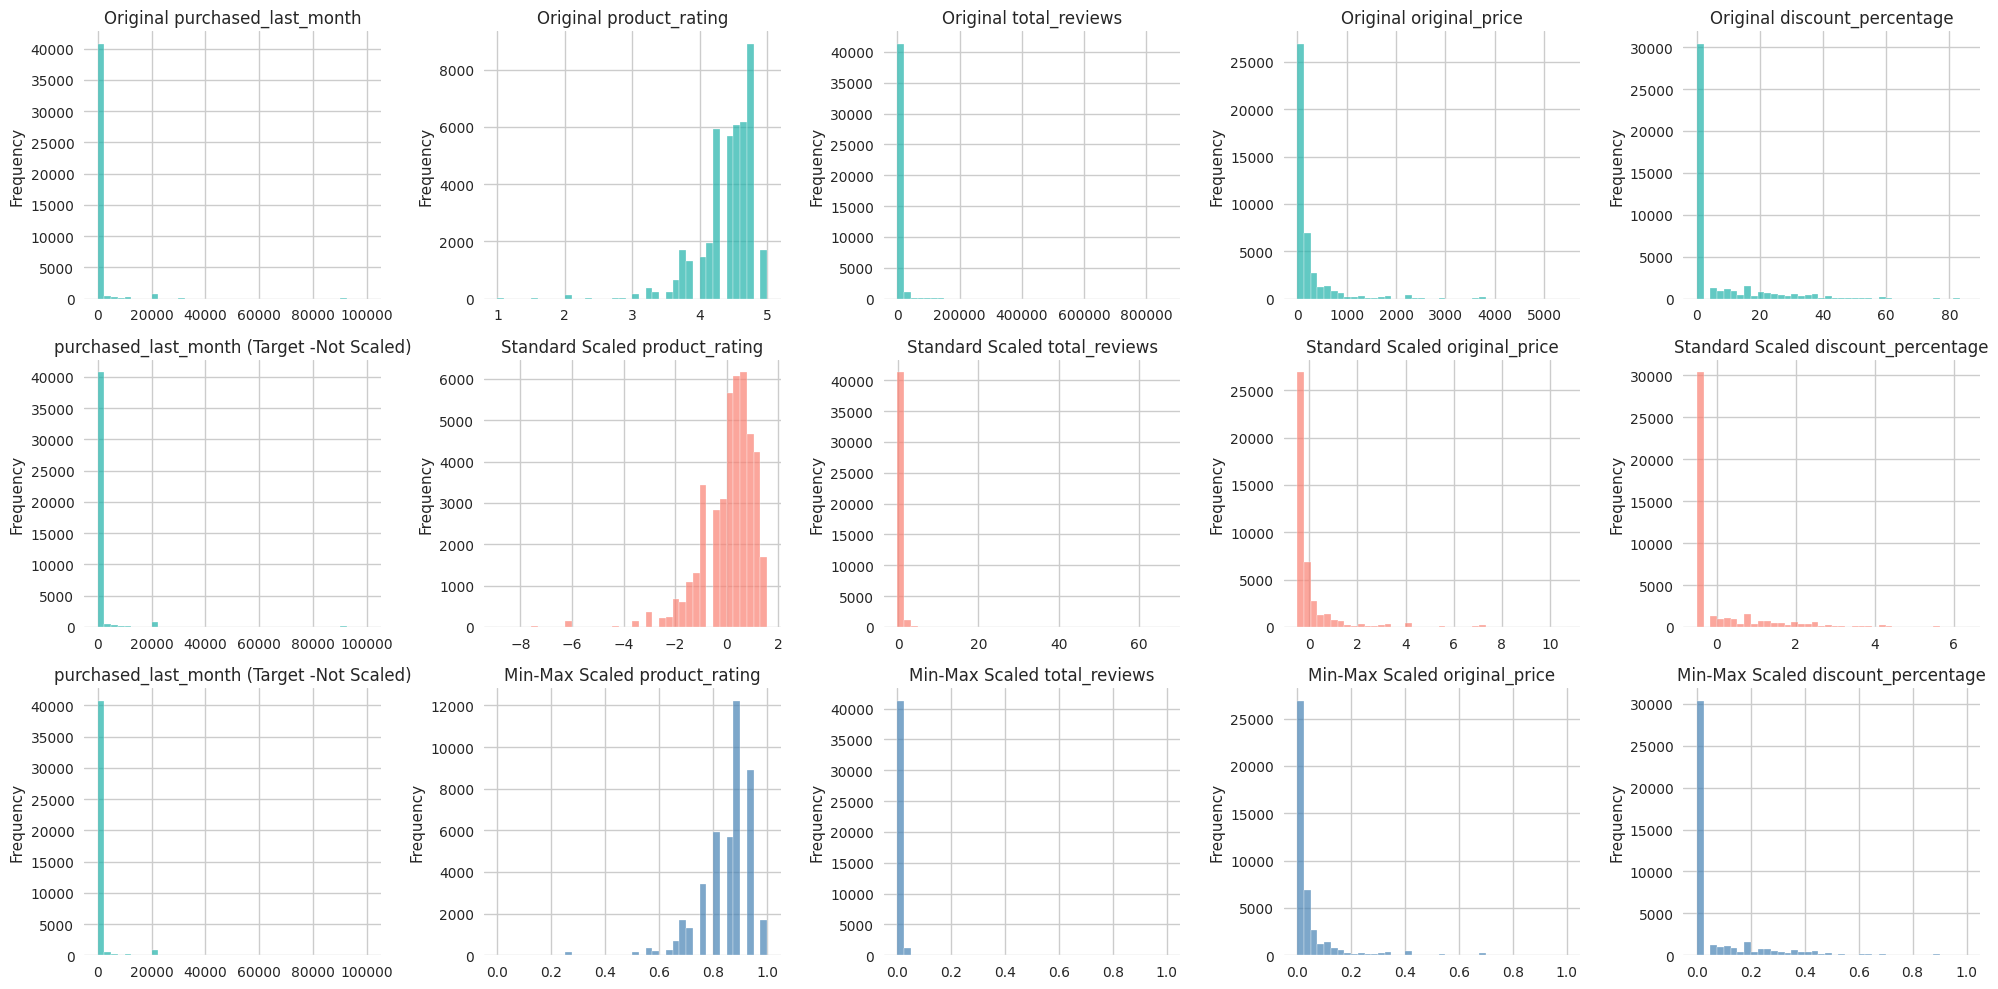

In [ ]:
# Compare scaling methods
fig, axes = plt.subplots(3, 5, figsize=(20, 10))

# Select a few key features for comparison
comparison_features = ['purchased_last_month', 'product_rating', 'total_reviews', 'original_price', 'discount_percentage']

for i, feature in enumerate(comparison_features):
  #Original
  axes[0, i].hist(df_processed[feature], bins=40, alpha=0.7, color='lightseagreen')
  axes[0, i].set_title(f'Original {feature}')
  axes[0, i].set_ylabel('Frequency')

  if feature != 'purchased_last_month': #Not scaling the target variable
    #Standard scaled
    axes[1, i].hist(df_standard_scaled[feature], bins=40, alpha=0.7, color='salmon')
    axes[1, i].set_title(f'Standard Scaled {feature}')
    axes[1, i].set_ylabel('Frequency')

    #Min-max scaled
    axes[2, i].hist(df_minmax_scaled[feature], bins=40, alpha=0.7, color='steelblue')
    axes[2, i].set_title(f'Min-Max Scaled {feature}')
    axes[2, i].set_ylabel('Frequency')

  else:
    #For purchased_last_month show same distribution
    axes[1, i].hist(df_processed[feature], bins=40, alpha=0.7, color='lightseagreen')
    axes[1, i].set_title(f'{feature} (Target -Not Scaled)')
    axes[1, i].set_ylabel('Frequency')

    axes[2, i].hist(df_processed[feature], bins=40, alpha=0.7, color='lightseagreen')
    axes[2, i].set_title(f'{feature} (Target -Not Scaled)')
    axes[2, i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## Step 5: Outlier Detection and Treatment
Outliers can significantly impact model performance.

In [ ]:
# Detect outliers using IQR method
numerical_cols = ["product_rating", "total_reviews", "purchased_last_month",
                  "discounted_price", "original_price", "discount_percentage"]

print("Outlier Detection Results (IQR Method):\n")
# Detect outliers in key numerical columns
for col in numerical_cols:
    if col in df.columns:
        # Drop missing values
        data = df[col].dropna()

        # Compute Q1, Q3, and IQR
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1

        # Define outlier boundaries
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Identify outliers
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]

        print(f"{col}: {len(outliers)} outliers detected")
        print(f"   Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
        print(f"   Example outlier values: {outliers.head(5).to_list()}\n")

# Optional: Highlight outliers in 'purchased_last_month'
print("Sample of detected outliers for 'purchased_last_month':")
outlier_rows = df[(df["purchased_last_month"] < df["purchased_last_month"].quantile(0.25) - 1.5 *
                  (df["purchased_last_month"].quantile(0.75) - df["purchased_last_month"].quantile(0.25))) |
                 (df["purchased_last_month"] > df["purchased_last_month"].quantile(0.75) + 1.5 *
                  (df["purchased_last_month"].quantile(0.75) - df["purchased_last_month"].quantile(0.25)))]

print(outlier_rows[["product_title", "purchased_last_month"]].head(10))

Outlier Detection Results (IQR Method):

product_rating: 924 outliers detected
   Lower Bound: 3.45, Upper Bound: 5.45
   Example outlier values: [2.8, 3.4, 3.4, 3.4, 3.3]

total_reviews: 5862 outliers detected
   Lower Bound: -2624.00, Upper Bound: 4592.00
   Example outlier values: [35882.0, 28988.0, 44522.0, 13466.0, 38105.0]

purchased_last_month: 4511 outliers detected
   Lower Bound: -350.00, Upper Bound: 850.00
   Example outlier values: [6000.0, 2000.0, 10000.0, 10000.0, 100000.0]

discounted_price: 4888 outliers detected
   Lower Bound: -261.78, Upper Bound: 515.47
   Example outlier values: [880.95, 1647.21, 569.95, 540.75, 919.08]

original_price: 5069 outliers detected
   Lower Bound: -262.51, Upper Bound: 525.49
   Example outlier values: [880.95, 1647.21, 569.95, 540.75, 919.08]

discount_percentage: 5103 outliers detected
   Lower Bound: -12.73, Upper Bound: 21.23
   Example outlier values: [43.6, 37.52, 30.98, 30.67, 40.74]

Sample of detected outliers for 'purchased_la

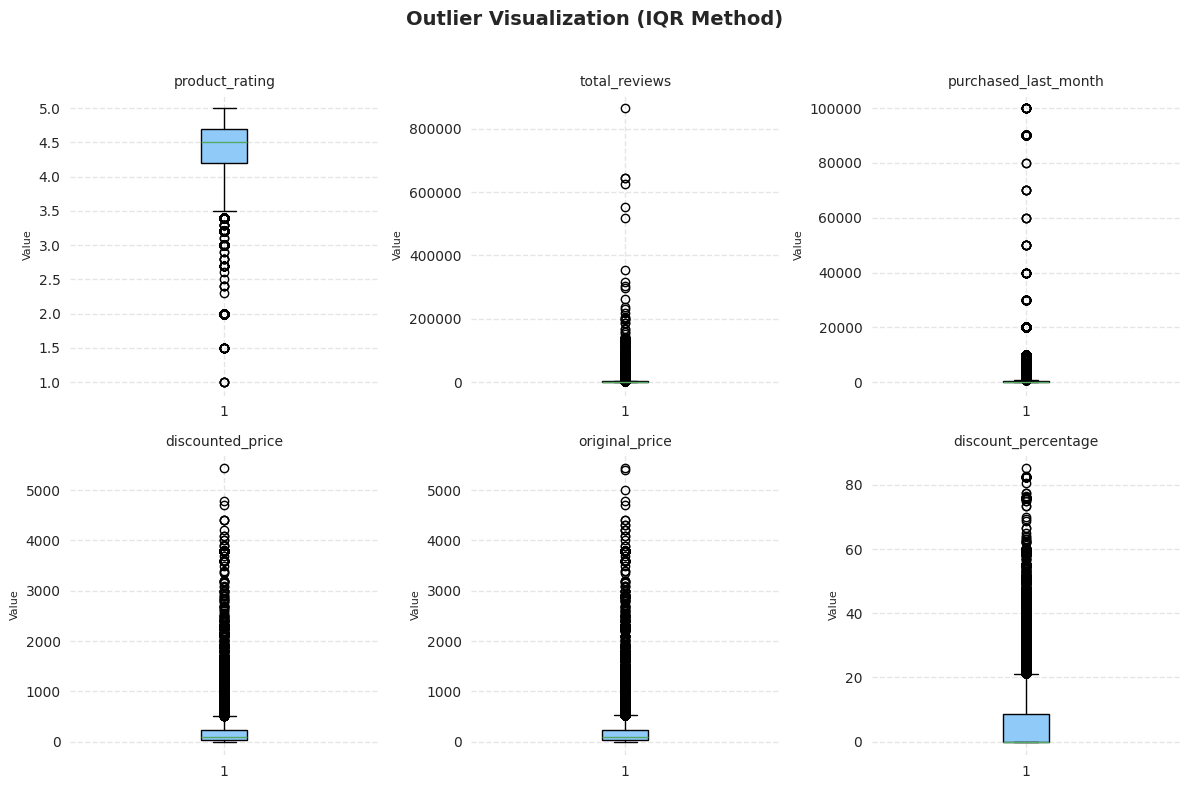

In [ ]:
# Visualize outliers
plt.figure(figsize=(12, 8))
plt.suptitle("Outlier Visualization (IQR Method)", fontsize=14, fontweight="bold")

# Loop through numerical columns to plot boxplots
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    plt.boxplot(df[col].dropna(), vert=True, patch_artist=True, boxprops=dict(facecolor="#90CAF9"))
    plt.title(col, fontsize=10)
    plt.ylabel("Value", fontsize=8)
    plt.grid(True, linestyle="--", alpha=0.5)

# for loop
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [ ]:
# Handle outliers - we'll use capping (Winsorization)
for col in numerical_cols:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        # Apply capping: replace values beyond bounds with the boundary
        df[col] = df[col].apply(
            lambda x: upper if x > upper else (lower if x < lower else x)
        )

        print(f"\n{col} outlier treatment:")
        print(f"  Values capped below {lower:.2f}: {len(df_processed[df_processed[col] < lower])}")
        print(f"  Values capped above {upper:.2f}: {len(df_processed[df_processed[col] > upper])}")

print("\nOutlier treatment completed using Winsorization (capping).")


product_rating outlier treatment:
  Values capped below 3.45: 924
  Values capped above 5.45: 0

total_reviews outlier treatment:
  Values capped below -2624.00: 0
  Values capped above 4592.00: 5862

purchased_last_month outlier treatment:
  Values capped below -350.00: 0
  Values capped above 850.00: 4511

discounted_price outlier treatment:
  Values capped below -261.78: 0
  Values capped above 515.47: 4911

original_price outlier treatment:
  Values capped below -262.51: 0
  Values capped above 525.49: 5092

discount_percentage outlier treatment:
  Values capped below -12.73: 0
  Values capped above 21.23: 5103

Outlier treatment completed using Winsorization (capping).


## Step 6: Feature Engineering
Creating new features that might be more predictive than the original ones.

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Create new features based on domain knowledge
# df_engineered = df_outlier_treated.copy() # Removed unused variable and dataframe copy

print("Creating new features...")

# Track new features
new_features = []

# =============================================================================
# TOP 10 MOST IMPACTFUL FEATURES
# =============================================================================

# New feature 1: Discount percentage
# Why: Direct indicator of price reduction, strong driver of purchases
df['discount_percentage'] = (
    (df['original_price'] - df['discounted_price']) /
    df['original_price'] * 100
).fillna(0)
new_features.append('discount_percentage')

# New feature 2: Quality score (rating × log of reviews)
# Why: Combines rating quality with social proof, highly predictive
df['quality_score'] = (
    df['product_rating'] * np.log1p(df['total_reviews'])
)
new_features.append('quality_score')

# New feature 3: Price per rating point
# Why: Value perception - how much you pay for quality
df['price_per_rating_point'] = (
    df['discounted_price'] / (df['product_rating'] + 0.01)
)
new_features.append('price_per_rating_point')

# New feature 4: Log of price
# Why: Handles price skewness, normalizes wide price range
df['log_price'] = np.log1p(df['discounted_price'])
new_features.append('log_price')

# New feature 5: Rating vs category average
# Why: Relative quality matters - is this product better than similar items?
df['category_avg_rating'] = (
    df.groupby('category')['product_rating'].transform('mean')
)
df['rating_vs_category'] = (
    df['product_rating'] - df['category_avg_rating']
)
new_features.append('rating_vs_category')

# New feature 6: Price vs category average
# Why: Price competitiveness within category
df['category_avg_price'] = (
    df.groupby('category')['discounted_price'].transform('mean')
)
df['price_vs_category'] = (
    df['discounted_price'] - df['category_avg_price']
)
new_features.append('price_vs_category')

# New feature 7: Discount on quality (discount × rating)
# Why: Captures "great deal on great product" phenomenon
df['discount_on_quality'] = (
    df['discount_percentage'] * df['product_rating']
)
new_features.append('discount_on_quality')

# New feature 8: High value product (binary)
# Why: Identifies sweet spot products (good quality + affordable price)
median_price = df['discounted_price'].median()
median_rating = df['product_rating'].median()
df['high_value_product'] = (
    (df['product_rating'] >= median_rating) &
    (df['discounted_price'] <= median_price)
).astype(int)
new_features.append('high_value_product')

# New feature 9: Log of total reviews
# Why: Social proof indicator, handles skewed distribution
df['log_reviews'] = np.log1p(df['total_reviews'])
new_features.append('log_reviews')

# New feature 10: Category encoded
# Why: Different categories have different purchase patterns
le_category = LabelEncoder()
df['category_encoded'] = le_category.fit_transform(df['category'])
new_features.append('category_encoded')

# =============================================================================
# PRINT SUMMARY
# =============================================================================

print("\nNew features created:")
for feature in new_features:
    print(f"  • {feature}")

print(f"\nDataset shape after feature engineering: {df.shape}")
print(f"Number of new features created: {len(new_features)}")

# Display sample of new features
print("\n" + "="*70)
print("SAMPLE OF NEW FEATURES")
print("="*70)
display_features = [
    'discount_percentage', 'quality_score', 'price_per_rating_point',
    'rating_vs_category', 'discount_on_quality', 'high_value_product'
]
print(df[display_features].head(10))

print("\n" + "="*70)
print("FEATURE DESCRIPTIONS")
print("="*70)
print("""
1. discount_percentage: How much discount offered (0-100%)
2. quality_score: Rating weighted by review count (social proof)
3. price_per_rating_point: Price divided by rating (value metric)
4. log_price: Log-transformed price (handles skewness)
5. rating_vs_category: Rating compared to category average
6. price_vs_category: Price compared to category average
7. discount_on_quality: Interaction of discount and quality
8. high_value_product: Binary flag for good quality + affordable
9. log_reviews: Log-transformed review count
10. category_encoded: Numerical encoding of product category
""")

Creating new features...

New features created:
  • discount_percentage
  • quality_score
  • price_per_rating_point
  • log_price
  • rating_vs_category
  • price_vs_category
  • discount_on_quality
  • high_value_product
  • log_reviews
  • category_encoded

Dataset shape after feature engineering: (42675, 29)
Number of new features created: 10

SAMPLE OF NEW FEATURES
   discount_percentage  quality_score  price_per_rating_point  \
0            43.597484      27.276110               19.453362   
1            37.523452      33.570544                2.317865   
2            10.028653      36.897778               68.112798   
3             0.000000      38.788528               35.193059   
4             0.000000      40.474986               15.122661   
5             0.000000      38.788528               21.681128   
6             0.000000      37.945299               19.536585   
7             0.000000      38.788528                4.997831   
8             0.000000      33.540129     

Analyzing new feature distributions...



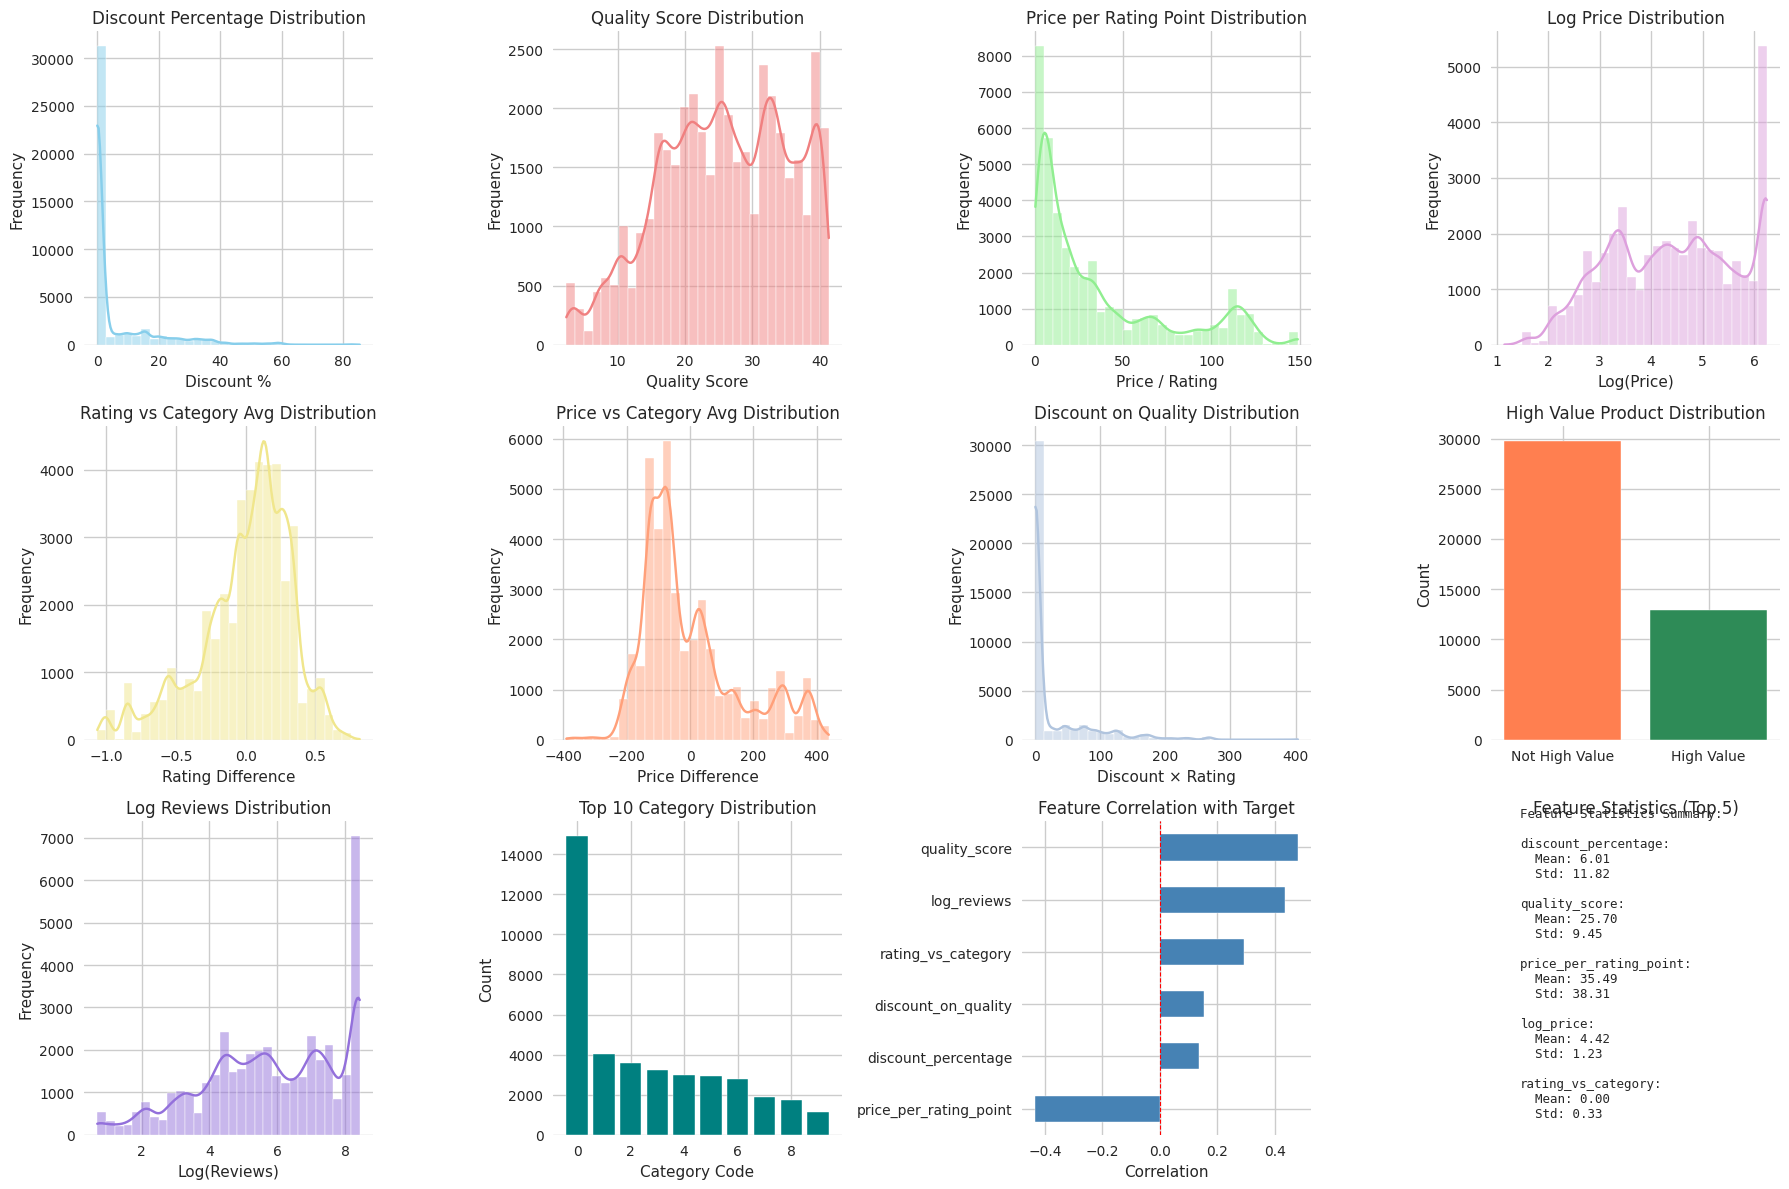


DETAILED FEATURE STATISTICS
                          count          mean         std         min  \
discount_percentage     42675.0  6.006697e+00   11.817656    0.000000   
quality_score           41651.0  2.569818e+01    9.445961    2.391358   
price_per_rating_point  39590.0  3.548633e+01   38.312935    0.458599   
log_price               40613.0  4.420806e+00    1.229751    1.150572   
rating_vs_category      41651.0  8.120293e-17    0.331852   -1.062082   
price_vs_category       40613.0 -4.657989e-15  155.987993 -390.962359   
discount_on_quality     41651.0  2.669200e+01   52.708342    0.000000   
high_value_product      42675.0  3.033626e-01    0.459716    0.000000   
log_reviews             41651.0  5.800894e+00    2.018768    0.693147   
category_encoded        42675.0  6.280187e+00    3.188185    0.000000   

                               25%        50%        75%         max  
discount_percentage       0.000000   0.000000   5.506598   85.415586  
quality_score            

In [ ]:
# Analyze the new features
print("Analyzing new feature distributions...\n")

# Set style
sns.set_style("whitegrid")
plt.figure(figsize=(18, 12))

# New feature 1 distribution: discount_percentage
plt.subplot(3, 4, 1)
sns.histplot(df['discount_percentage'], bins=30, kde=True, color='skyblue')
plt.title('Discount Percentage Distribution')
plt.xlabel('Discount %')
plt.ylabel('Frequency')

# New feature 2 distribution: quality_score
plt.subplot(3, 4, 2)
sns.histplot(df['quality_score'], bins=30, kde=True, color='lightcoral')
plt.title('Quality Score Distribution')
plt.xlabel('Quality Score')
plt.ylabel('Frequency')

# New feature 3 distribution: price_per_rating_point
plt.subplot(3, 4, 3)
sns.histplot(df['price_per_rating_point'], bins=30, kde=True, color='lightgreen')
plt.title('Price per Rating Point Distribution')
plt.xlabel('Price / Rating')
plt.ylabel('Frequency')

# New feature 4 distribution: log_price
plt.subplot(3, 4, 4)
sns.histplot(df['log_price'], bins=30, kde=True, color='plum')
plt.title('Log Price Distribution')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

# New feature 5 distribution: rating_vs_category
plt.subplot(3, 4, 5)
sns.histplot(df['rating_vs_category'], bins=30, kde=True, color='khaki')
plt.title('Rating vs Category Avg Distribution')
plt.xlabel('Rating Difference')
plt.ylabel('Frequency')

# New feature 6 distribution: price_vs_category
plt.subplot(3, 4, 6)
sns.histplot(df['price_vs_category'], bins=30, kde=True, color='lightsalmon')
plt.title('Price vs Category Avg Distribution')
plt.xlabel('Price Difference')
plt.ylabel('Frequency')

# New feature 7 distribution: discount_on_quality
plt.subplot(3, 4, 7)
sns.histplot(df['discount_on_quality'], bins=30, kde=True, color='lightsteelblue')
plt.title('Discount on Quality Distribution')
plt.xlabel('Discount × Rating')
plt.ylabel('Frequency')

# New feature 8 distribution: high_value_product
plt.subplot(3, 4, 8)
high_value_counts = df['high_value_product'].value_counts()
plt.bar(['Not High Value', 'High Value'], high_value_counts.values, color=['coral', 'seagreen'])
plt.title('High Value Product Distribution')
plt.ylabel('Count')

# New feature 9 distribution: log_reviews
plt.subplot(3, 4, 9)
sns.histplot(df['log_reviews'], bins=30, kde=True, color='mediumpurple')
plt.title('Log Reviews Distribution')
plt.xlabel('Log(Reviews)')
plt.ylabel('Frequency')

# New feature 10 distribution: category_encoded
plt.subplot(3, 4, 10)
category_counts = df['category_encoded'].value_counts().head(10)
plt.bar(range(len(category_counts)), category_counts.values, color='teal')
plt.title('Top 10 Category Distribution')
plt.xlabel('Category Code')
plt.ylabel('Count')

# Bonus: Correlation with target variable
plt.subplot(3, 4, 11)
correlations = df[[
    'discount_percentage', 'quality_score', 'price_per_rating_point',
    'rating_vs_category', 'discount_on_quality', 'log_reviews',
    'purchased_last_month' # Corrected typo here
]].corr()['purchased_last_month'].drop('purchased_last_month').sort_values() # Corrected typo here

correlations.plot(kind='barh', color='steelblue')
plt.title('Feature Correlation with Target')
plt.xlabel('Correlation')
plt.axvline(x=0, color='red', linestyle='--', linewidth=0.8)

# Bonus: Feature statistics summary
plt.subplot(3, 4, 12)
plt.axis('off')
stats_text = "Feature Statistics Summary:\n\n"
# Assuming 'new_features' is a list of the names of the newly created features
if 'new_features' in locals() and isinstance(new_features, list):
    for feature in new_features[:5]:  # Show first 5
        if feature in df.columns:
            mean_val = df[feature].mean()
            std_val = df[feature].std()
            stats_text += f"{feature}:\n  Mean: {mean_val:.2f}\n  Std: {std_val:.2f}\n\n"
else:
    stats_text += "Error: 'new_features' list not found."

plt.text(0.1, 0.5, stats_text, fontsize=9, verticalalignment='center', family='monospace')
plt.title('Feature Statistics (Top 5)')

plt.tight_layout()
plt.show()

# Print detailed statistics
print("\n" + "="*70)
print("DETAILED FEATURE STATISTICS")
print("="*70)
# Ensure 'new_features' is available and is a list
if 'new_features' in locals() and isinstance(new_features, list):
    print(df[new_features].describe().T)
else:
    print("Cannot display detailed statistics: 'new_features' list not found.")

## Step 7: Feature Selection
Not all features are equally important. Let's identify the most predictive ones.


Correlation with target:
quality_score             0.480382
total_reviews             0.473065
log_reviews               0.436543
rating_vs_category        0.291552
product_rating            0.275930
discount_on_quality       0.153519
discount_percentage       0.137184
price_vs_category        -0.373327
original_price           -0.430922
discounted_price         -0.431064
price_per_rating_point   -0.433172
log_price                -0.538143
dtype: float64


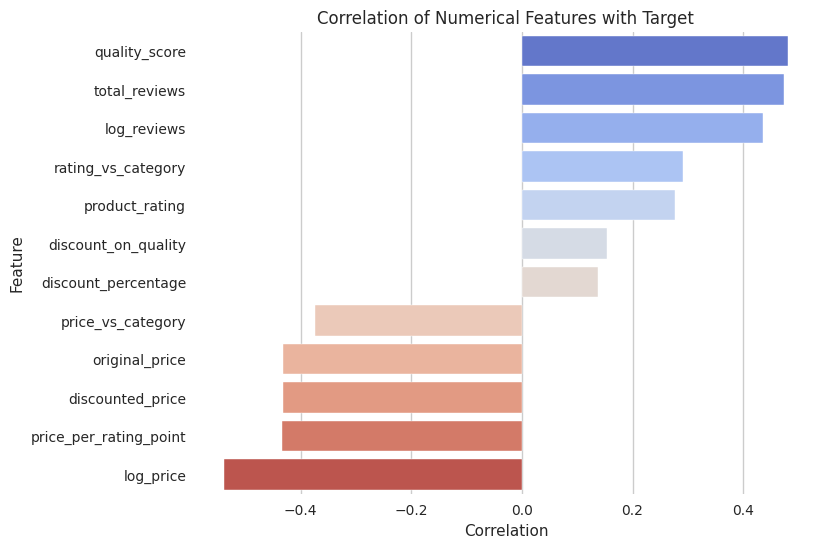

In [ ]:
# Prepare features
X = df.drop(['purchased_last_month', 'product_title', 'Status'], axis=1, errors='ignore')
y = df['purchased_last_month']

# Drop rows where target is NaN
mask = y.notna()
X = X[mask]
y = y[mask]

# Select numerical features for correlation analysis
numerical_features = [
    'product_rating', 'total_reviews', 'original_price', 'discounted_price',
    'discount_percentage', 'quality_score', 'price_per_rating_point', 'log_price',
    'rating_vs_category', 'price_vs_category', 'discount_on_quality', 'log_reviews'
]

# Subset numerical features
X_corr = X[numerical_features]
y_corr = y

# Calculate correlation with target
correlations = X_corr.corrwith(y_corr).sort_values(ascending=False)
print("\nCorrelation with target:")
print(correlations)

# Visualize correlation
plt.figure(figsize=(8,6))
sns.barplot(x=correlations.values, y=correlations.index, palette='coolwarm')
plt.title('Correlation of Numerical Features with Target')
plt.xlabel('Correlation')
plt.ylabel('Feature')
plt.show()


Random Forest Feature Importances:
price_per_rating_point    0.274608
quality_score             0.183768
original_price            0.127190
price_vs_category         0.093521
product_rating            0.072108
rating_vs_category        0.061537
log_price                 0.038418
discounted_price          0.038057
total_reviews             0.032607
log_reviews               0.032371
discount_on_quality       0.024838
discount_percentage       0.020977
dtype: float64


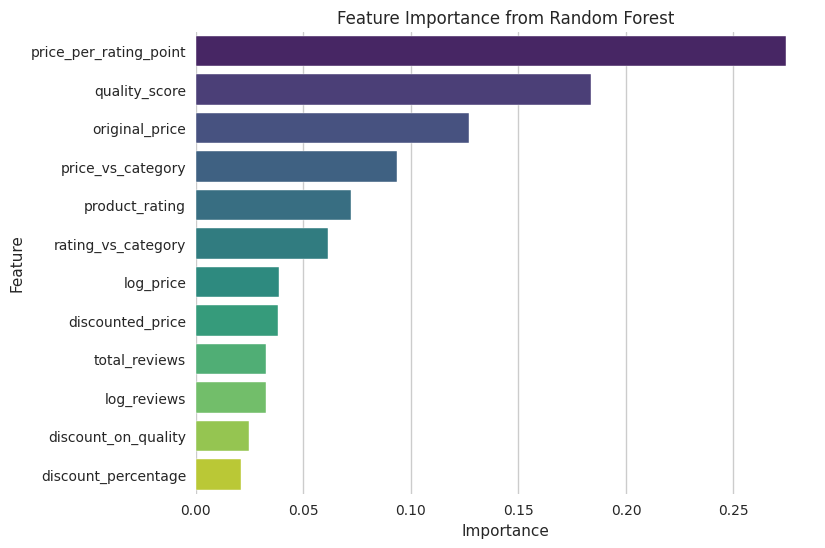


Top features selected for modeling:
['price_per_rating_point', 'quality_score', 'original_price', 'price_vs_category', 'product_rating', 'rating_vs_category', 'log_price', 'discounted_price', 'total_reviews', 'log_reviews', 'discount_on_quality', 'discount_percentage']


In [ ]:
# Use Random Forest for feature importance
# Prepare features (only numerical for this example)
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_corr, y_corr)
# Train a Random Forest to get feature importance
# Get feature importance
rf_importances = pd.Series(rf.feature_importances_, index=numerical_features).sort_values(ascending=False)
print("\nRandom Forest Feature Importances:")
print(rf_importances)
# Visualize feature importance
plt.figure(figsize=(8,6))
sns.barplot(x=rf_importances.values, y=rf_importances.index, palette='viridis')
plt.title('Feature Importance from Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

# Select top features for modeling
top_features = rf_importances[rf_importances > 0.02].index.tolist()
print("\nTop features selected for modeling:")
print(top_features)

## Step 8: Building a Preprocessing Pipeline
Let's create a reusable pipeline for all our preprocessing steps.

In [ ]:
# Create a comprehensive preprocessing pipeline
# Define column groups
numerical_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

# Numerical pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # Fill missing numerical values
    ('scaler', StandardScaler())                    # Standard scaling
])

# Categorical pipeline
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Fill missing categorical values
    ('encoder', OneHotEncoder(handle_unknown='ignore'))    # One-hot encoding
])

# Combine pipelines
preprocessor = ColumnTransformer([
    ('num', num_pipeline, numerical_cols),
    ('cat', cat_pipeline, categorical_cols)
])

In [ ]:
# Test the pipeline on our data
# Start with original data (with missing values)
X_raw = X.copy()

# Split the data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=42)

# Apply preprocessing pipeline
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

print("Preprocessing pipeline applied successfully.")
print("Training data shape after preprocessing:", X_train_processed.shape)
print("Test data shape after preprocessing:", X_test_processed.shape)

Preprocessing pipeline applied successfully.
Training data shape after preprocessing: (25731, 30449)
Test data shape after preprocessing: (6433, 30449)


In [ ]:
# Get numerical features (unchanged)
num_features_after = numerical_cols

# Get categorical features AFTER fitting
# Access the fitted encoder via the pipeline inside ColumnTransformer
cat_encoder_fitted = preprocessor.named_transformers_['cat'].named_steps['encoder']
cat_features_after = cat_encoder_fitted.get_feature_names_out(categorical_cols)

# Combine all feature names
all_features_after = list(num_features_after) + list(cat_features_after)

print(f"Total features after preprocessing: {len(all_features_after)}")
print("feature names:")
print(all_features_after[:20])

Total features after preprocessing: 30449
feature names:
['product_rating', 'total_reviews', 'discounted_price', 'original_price', 'discount_percentage', 'quality_score', 'price_per_rating_point', 'log_price', 'category_avg_rating', 'rating_vs_category', 'category_avg_price', 'price_vs_category', 'discount_on_quality', 'high_value_product', 'log_reviews', 'category_encoded', "is_best_seller_Amazon's", 'is_best_seller_Best Seller', 'is_best_seller_Ends in', 'is_best_seller_Limited time deal']


##FINAL EXAM PORTION <a name='finalexam' />

## 🔹 Section 1: Train/Validation/Test Split & Linear Regression (John)

In this section, I create the 70/15/15 split for our final ML project and run the first required model: Linear Regression.

I use the cleaned dataset from the midterm and apply our existing preprocessing pipeline.


In [ ]:
# ========================================
# BLOCK 1 — Reset Modeling DataFrame
# ========================================

# Use the final cleaned dataset from the midterm
df_model = df_processed.copy()   # <-- Use the fully cleaned dataset

print("Modeling DataFrame Shape:", df_model.shape)

# ========================================
# Define Regression Target (y) and Features (X)
# ========================================

# Regression target
y = df_model['purchased_last_month']

# Drop target + non-feature text columns
X = df_model.drop([
    'purchased_last_month',
    'product_title',
    'Status'
], axis=1, errors='ignore')

# Remove rows where target is missing
mask = y.notna()
X = X.loc[mask]
y = y.loc[mask]

print("X Shape:", X.shape)
print("y Shape:", y.shape)


Modeling DataFrame Shape: (42675, 39)
X Shape: (42675, 37)
y Shape: (42675,)


In [ ]:
# ========================================
# BLOCK 2 — Train / Validation / Test Split
# ========================================

from sklearn.model_selection import train_test_split

# 70 percent train, 15 percent validation, 15 percent test
X_train_full, X_temp, y_train_full, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42
)

print("Train size:", X_train_full.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)


Train size: (29872, 37)
Validation size: (6401, 37)
Test size: (6402, 37)


In [ ]:
# ========================================
# BLOCK 3 — Build & Apply Preprocessing Pipeline
# ========================================

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# Identify column types from X (the FINAL modeling dataset)
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Numeric cols:", len(num_cols))
print("Categorical cols:", len(cat_cols))

# Numerical preprocessing
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combined preprocessing
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

# Fit only on training set and transform all sets
X_train = preprocessor.fit_transform(X_train_full)
X_val   = preprocessor.transform(X_val)
X_test  = preprocessor.transform(X_test)

print("Shapes after preprocessing:")
print("X_train:", X_train.shape)
print("X_val:",   X_val.shape)
print("X_test:",  X_test.shape)


Numeric cols: 8
Categorical cols: 10
Shapes after preprocessing:
X_train: (29872, 5968)
X_val: (6401, 5968)
X_test: (6402, 5968)


In [ ]:
# ========================================
# BLOCK 4 — Linear Regression Model
# ========================================

from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()

# Fit model
lin_reg.fit(X_train, y_train_full)

print("Linear Regression training complete.")


Linear Regression training complete.


In [ ]:
# ========================================
# BLOCK 5 — Decision Tree Regressor
# ========================================

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Training Decision Tree Regressor...")

dt_reg = DecisionTreeRegressor(
    max_depth=None,
    random_state=42
)

# IMPORTANT: X_train must be paired with y_train_full (not y_train)
dt_reg.fit(X_train, y_train_full)

print("Decision Tree training complete.")

# Predict on validation set
dt_val_pred = dt_reg.predict(X_val)

# Compute metrics
dt_mae = mean_absolute_error(y_val, dt_val_pred)
dt_mse = mean_squared_error(y_val, dt_val_pred)
dt_r2  = r2_score(y_val, dt_val_pred)

print("\nDecision Tree Validation Metrics:")
print(f"MAE: {dt_mae:.4f}")
print(f"MSE: {dt_mse:.4f}")
print(f"R² : {dt_r2:.4f}")


Training Decision Tree Regressor...
Decision Tree training complete.

Decision Tree Validation Metrics:
MAE: 162.0056
MSE: 1136255.6181
R² : 0.9621


In [ ]:
# ============================================================
# BLOCK 6: Random Forest Regressor
# ============================================================
from sklearn.ensemble import RandomForestRegressor

print("Training Random Forest Regressor...")

rf_reg = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_reg.fit(X_train, y_train_full)

print("Random Forest training complete.")

Training Random Forest Regressor...
Random Forest training complete.


In [ ]:
# ============================================================
# BLOCK 7: Gradient Boosting Regressor
# ============================================================
from sklearn.ensemble import GradientBoostingRegressor

print("Training Gradient Boosting Regressor...")

gboost_reg = GradientBoostingRegressor(
    random_state=42,
    n_estimators=200,
    learning_rate=0.1
)
gboost_reg.fit(X_train, y_train_full)

print("Gradient Boosting training complete.")


Training Gradient Boosting Regressor...
Gradient Boosting training complete.


In [ ]:
# ============================================
# BLOCK 8: Gradient Boosting Predictions
# ============================================

# Predict on TRAIN, VAL, TEST
gb_train_pred = gboost_reg.predict(X_train)
gb_val_pred   = gboost_reg.predict(X_val)
gb_test_pred  = gboost_reg.predict(X_test)

print("Gradient Boosting predictions created:")
print("Train preds:", len(gb_train_pred))
print("Val preds:", len(gb_val_pred))
print("Test preds:", len(gb_test_pred))


Gradient Boosting predictions created:
Train preds: 29872
Val preds: 6401
Test preds: 6402


In [ ]:
# ============================================================
# BLOCK 9: K-Nearest Neighbors Regressor
# ============================================================
from sklearn.neighbors import KNeighborsRegressor

print("Training KNN Regressor...")

knn_reg = KNeighborsRegressor(
    n_neighbors=5,
    weights='distance'
)
knn_reg.fit(X_train, y_train_full)

print("KNN Regressor training complete.")


Training KNN Regressor...
KNN Regressor training complete.


In [ ]:
# ========================================
# BLOCK 10 — Generate Predictions for Validation & Test
# ========================================

# Linear Regression
lin_val_pred  = lin_reg.predict(X_val)
lin_test_pred = lin_reg.predict(X_test)

# Decision Tree
dt_val_pred  = dt_reg.predict(X_val)
dt_test_pred = dt_reg.predict(X_test)

# Random Forest
rf_val_pred  = rf_reg.predict(X_val)
rf_test_pred = rf_reg.predict(X_test)

# Gradient Boosting
gboost_val_pred  = gboost_reg.predict(X_val)
gboost_test_pred = gboost_reg.predict(X_test)

# KNN Regressor
knn_val_pred  = knn_reg.predict(X_val)
knn_test_pred = knn_reg.predict(X_test)

print("Predictions generated for all models.")


Predictions generated for all models.


In [ ]:
# ========================================
# BLOCK 10 — Model Evaluation & Comparison
# ========================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd

def compute_metrics(y_true, y_pred):
    """Return MAE, MSE, R² as a tuple."""
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    r2  = r2_score(y_true, y_pred)
    return mae, mse, r2

# Dictionary of models and predictions
models = {
    "Linear Regression":    (lin_val_pred,    lin_test_pred),
    "Decision Tree":        (dt_val_pred,     dt_test_pred),
    "Random Forest":        (rf_val_pred,     rf_test_pred),
    "Gradient Boosting":    (gboost_val_pred, gboost_test_pred),
    "KNN Regressor":        (knn_val_pred,    knn_test_pred)
}

# Build comparison table
results = []

for model_name, (val_pred, test_pred) in models.items():
    val_mae, val_mse, val_r2 = compute_metrics(y_val, val_pred)
    test_mae, test_mse, test_r2 = compute_metrics(y_test, test_pred)

    results.append({
        "Model": model_name,
        "Val MAE": val_mae,
        "Val MSE": val_mse,
        "Val R²":  val_r2,
        "Test MAE": test_mae,
        "Test MSE": test_mse,
        "Test R²":  test_r2
    })

# Convert to DataFrame for easy viewing
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("Val MAE")  # sort by performance (lower MAE is better)

print("\n=== MODEL PERFORMANCE COMPARISON ===")
display(results_df)



=== MODEL PERFORMANCE COMPARISON ===


,Model,Val MAE,Val MSE,Val R²,Test MAE,Test MSE,Test R²
2,Random Forest,160.055764,1.004542e+06,0.966520,193.565640,2.296585e+06,0.936463
1,Decision Tree,162.005558,1.136256e+06,0.962130,225.493886,4.094808e+06,0.886714
4,KNN Regressor,198.635652,1.965696e+06,0.934485,257.418653,3.252120e+06,0.910027
0,Linear Regression,325.635833,1.552248e+06,0.948265,378.661411,2.477571e+06,0.931456
3,Gradient Boosting,338.445630,1.182456e+06,0.960590,381.584256,3.761618e+06,0.895932


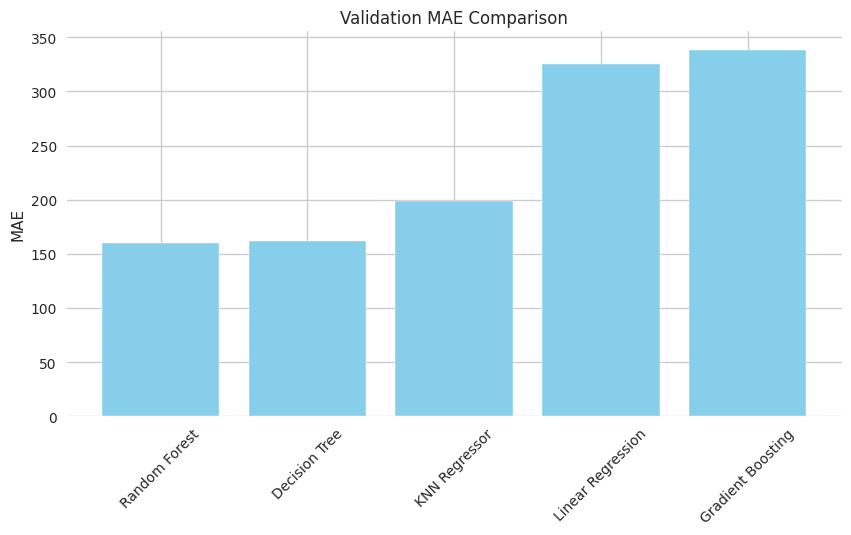

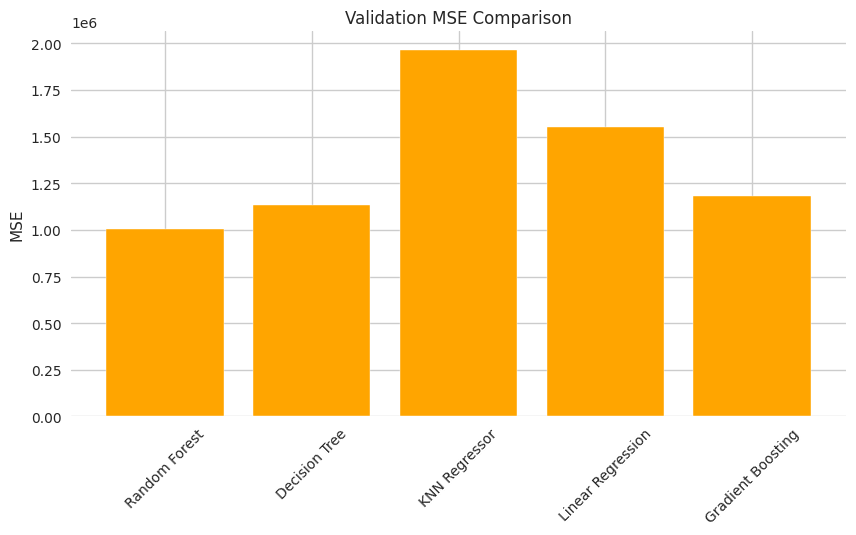

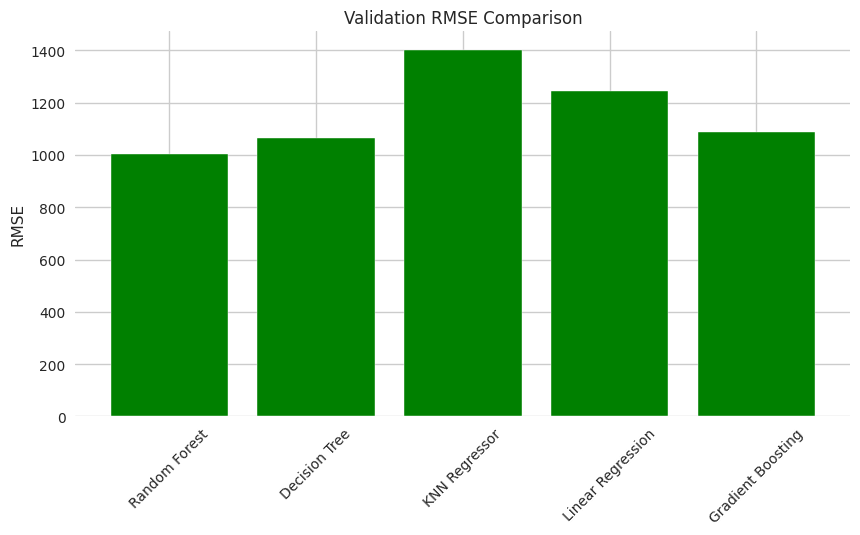

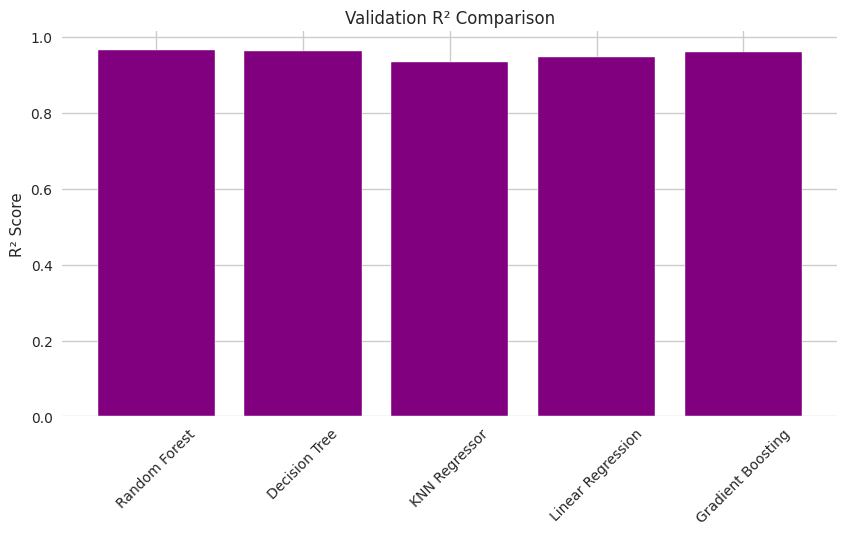

In [ ]:
# ========================================
# BLOCK 11 — Performance Visualization
# ========================================

import matplotlib.pyplot as plt
import numpy as np

# Extract values from results_df
models = results_df["Model"].tolist()

val_mae = results_df["Val MAE"].tolist()
val_mse = results_df["Val MSE"].tolist()
val_rmse = np.sqrt(results_df["Val MSE"]).tolist()
val_r2  = results_df["Val R²"].tolist()

# --- MAE ---
plt.figure(figsize=(10,5))
plt.bar(models, val_mae, color="skyblue")
plt.title("Validation MAE Comparison")
plt.ylabel("MAE")
plt.xticks(rotation=45)
plt.show()

# --- MSE ---
plt.figure(figsize=(10,5))
plt.bar(models, val_mse, color="orange")
plt.title("Validation MSE Comparison")
plt.ylabel("MSE")
plt.xticks(rotation=45)
plt.show()

# --- RMSE ---
plt.figure(figsize=(10,5))
plt.bar(models, val_rmse, color="green")
plt.title("Validation RMSE Comparison")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.show()

# --- R² ---
plt.figure(figsize=(10,5))
plt.bar(models, val_r2, color="purple")
plt.title("Validation R² Comparison")
plt.ylabel("R² Score")
plt.xticks(rotation=45)
plt.show()


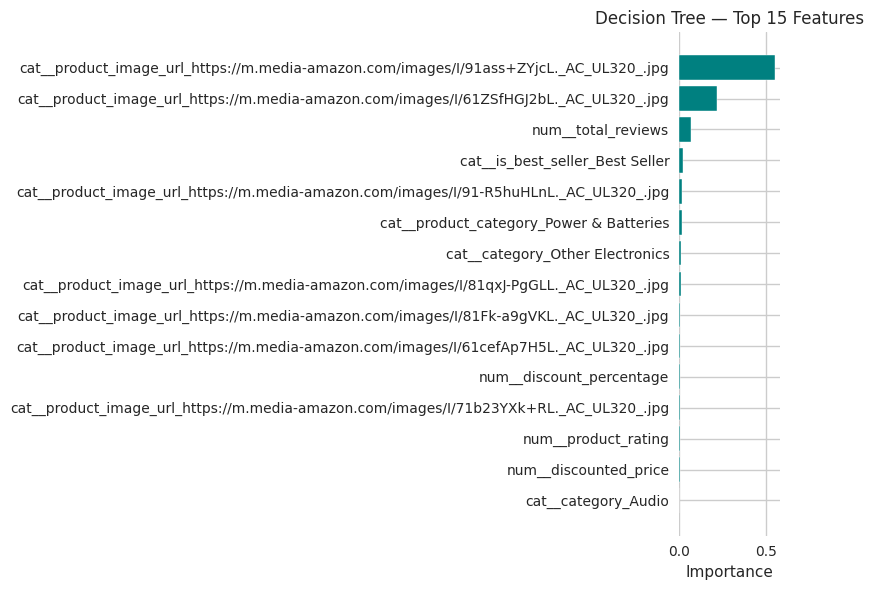

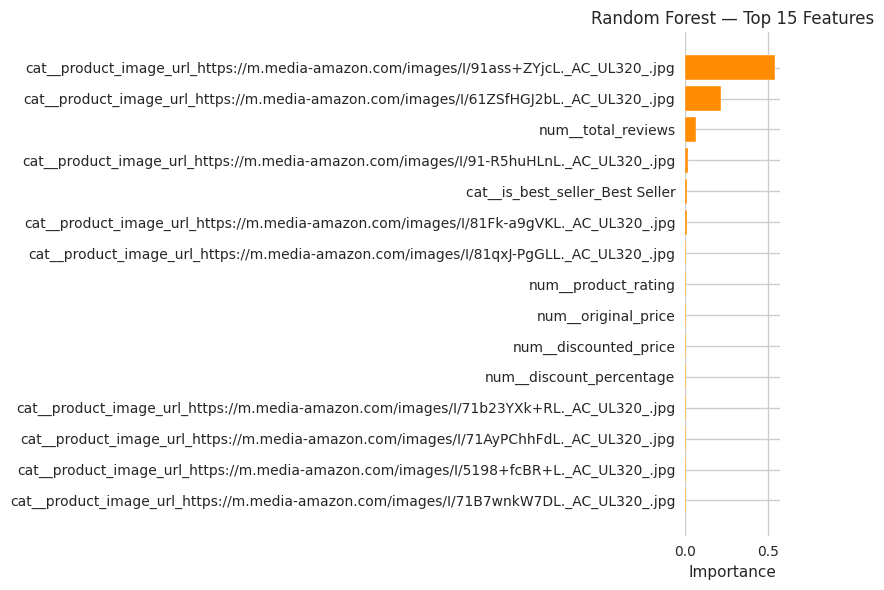

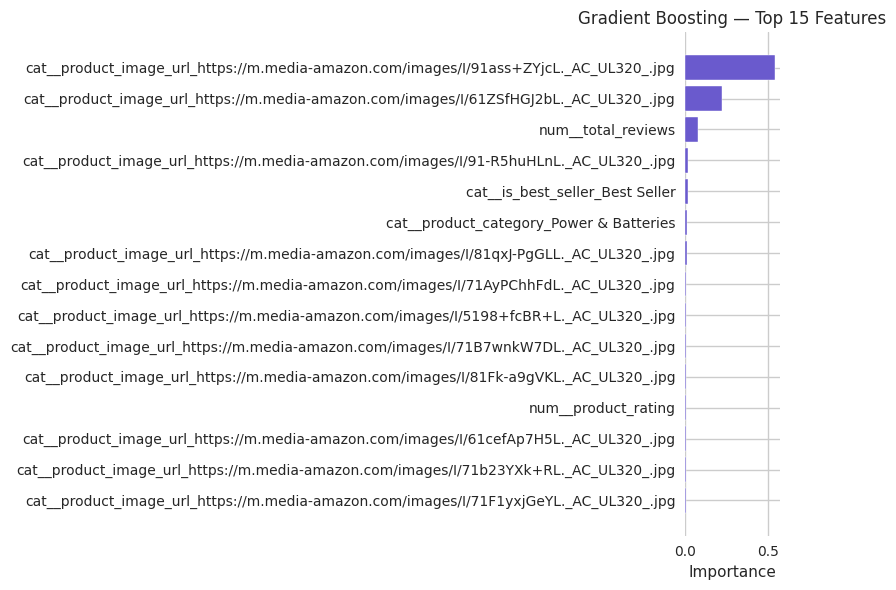

In [ ]:
# ========================================
# BLOCK 12 — Feature Importances
# ========================================

importances_dt = dt_reg.feature_importances_
importances_rf = rf_reg.feature_importances_
importances_gb = gboost_reg.feature_importances_

feature_names = preprocessor.get_feature_names_out()

def plot_top_features(importances, title, color):
    idx = np.argsort(importances)[-15:]  # top 15
    plt.figure(figsize=(8,6))
    plt.barh(np.array(feature_names)[idx], importances[idx], color=color)
    plt.title(title)
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

plot_top_features(importances_dt, "Decision Tree — Top 15 Features", "teal")
plot_top_features(importances_rf, "Random Forest — Top 15 Features", "darkorange")
plot_top_features(importances_gb, "Gradient Boosting — Top 15 Features", "slateblue")


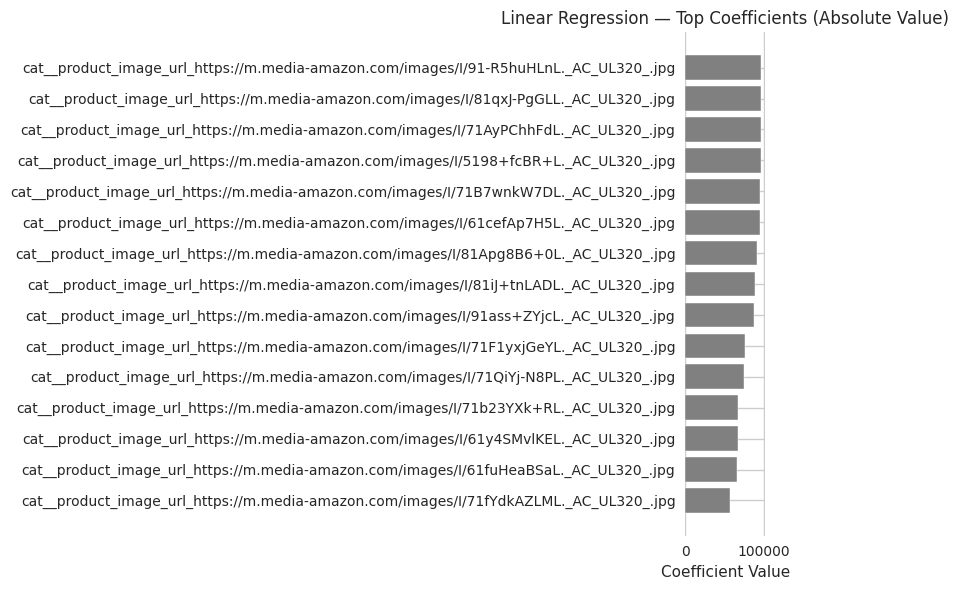

In [ ]:
# ========================================
# BLOCK 13 — Linear Regression Coefficients
# ========================================

coef = lin_reg.coef_

# Get largest magnitude coefficients
idx = np.argsort(np.abs(coef))[-15:]

plt.figure(figsize=(8,6))
plt.barh(np.array(feature_names)[idx], coef[idx], color="gray")
plt.title("Linear Regression — Top Coefficients (Absolute Value)")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.show()


❌ Why we skip KNN (no feature importances)

KNN is distance-based, not rule-based — it cannot compute any feature importance values.

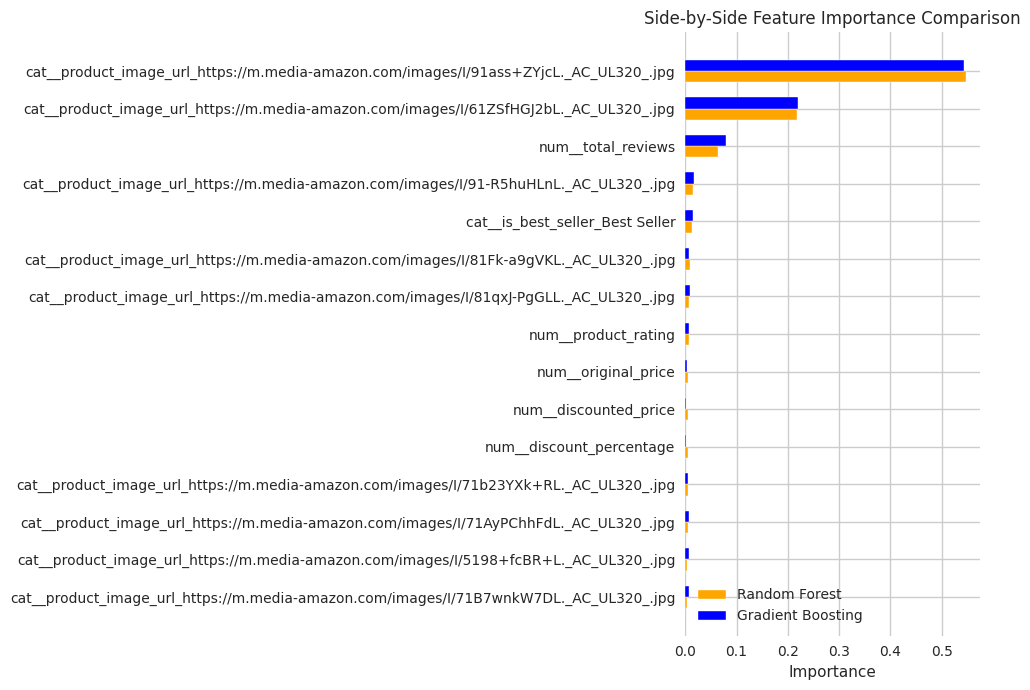

In [ ]:
# ========================================
# BLOCK 14 — Side-by-Side Feature Comparison
# ========================================

top_idx = np.argsort(importances_rf)[-15:]
features = np.array(feature_names)[top_idx]

plt.figure(figsize=(10,7))
x = np.arange(len(features))

plt.barh(x - 0.15, importances_rf[top_idx], 0.3, label="Random Forest", color="orange")
plt.barh(x + 0.15, importances_gb[top_idx], 0.3, label="Gradient Boosting", color="blue")

plt.yticks(x, features)
plt.title("Side-by-Side Feature Importance Comparison")
plt.xlabel("Importance")
plt.legend()
plt.tight_layout()
plt.show()


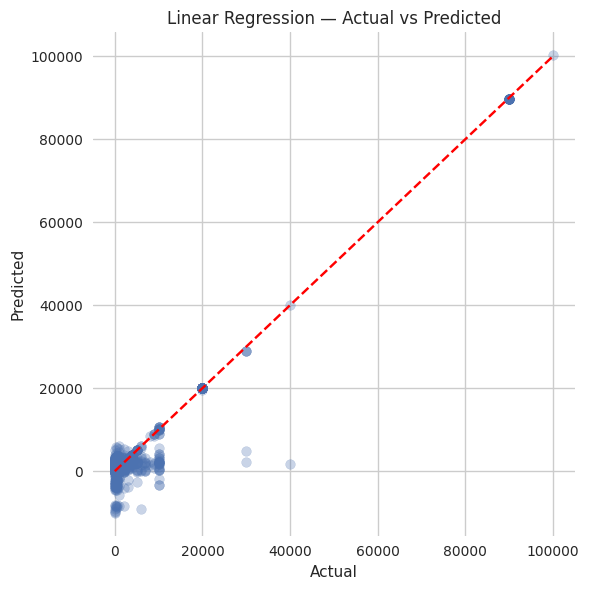

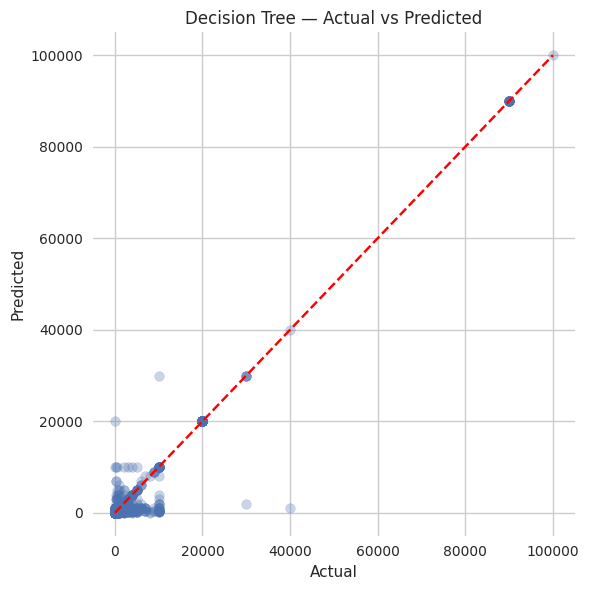

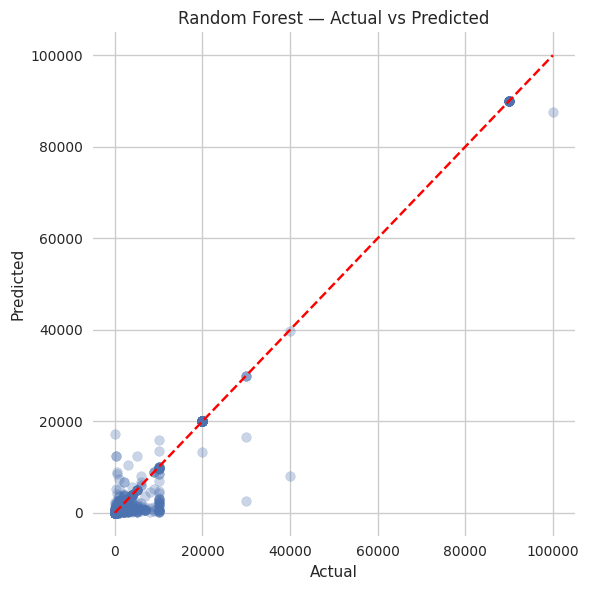

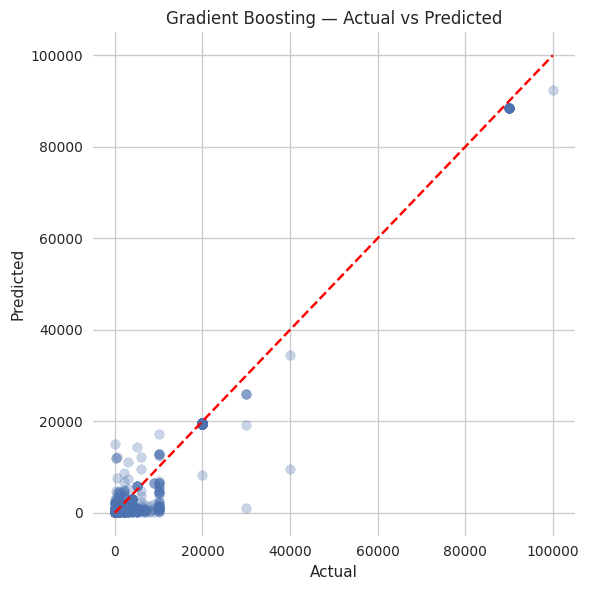

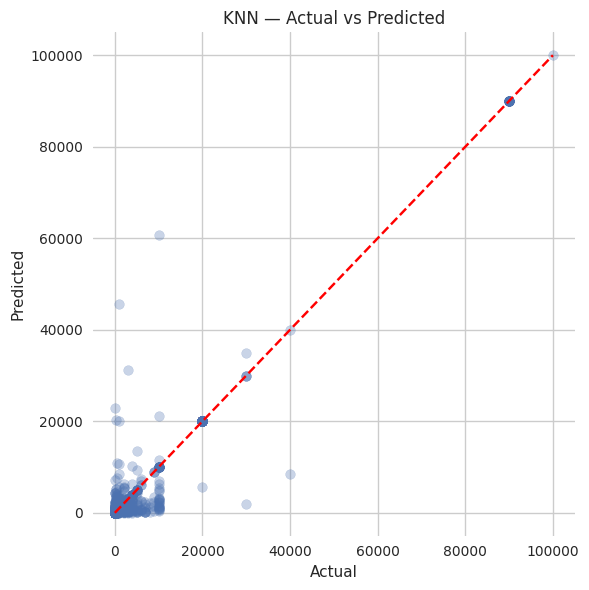

In [ ]:
# ========================================
# BLOCK 15 — Actual vs Predicted
# ========================================

def plot_actual_predicted(y_true, y_pred, title):
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, alpha=0.3)
    plt.plot([0, max(y_true)], [0, max(y_true)], color="red", linestyle="--")
    plt.title(title)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.tight_layout()
    plt.show()

plot_actual_predicted(y_val, lin_val_pred,    "Linear Regression — Actual vs Predicted")
plot_actual_predicted(y_val, dt_val_pred,     "Decision Tree — Actual vs Predicted")
plot_actual_predicted(y_val, rf_val_pred,     "Random Forest — Actual vs Predicted")
plot_actual_predicted(y_val, gboost_val_pred, "Gradient Boosting — Actual vs Predicted")
plot_actual_predicted(y_val, knn_val_pred,    "KNN — Actual vs Predicted")


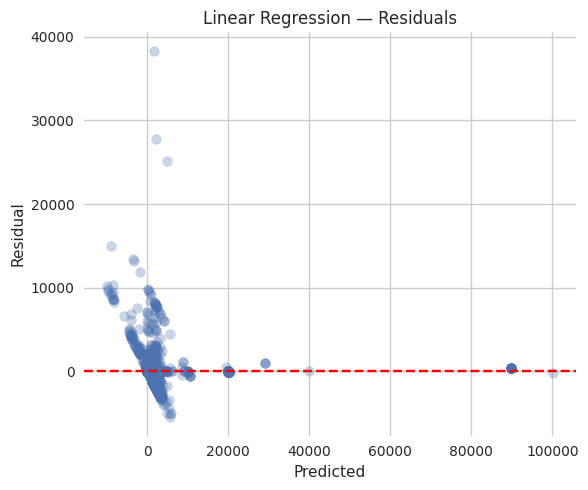

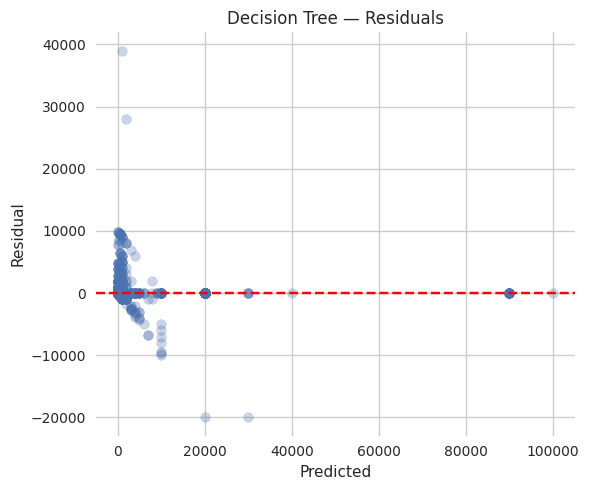

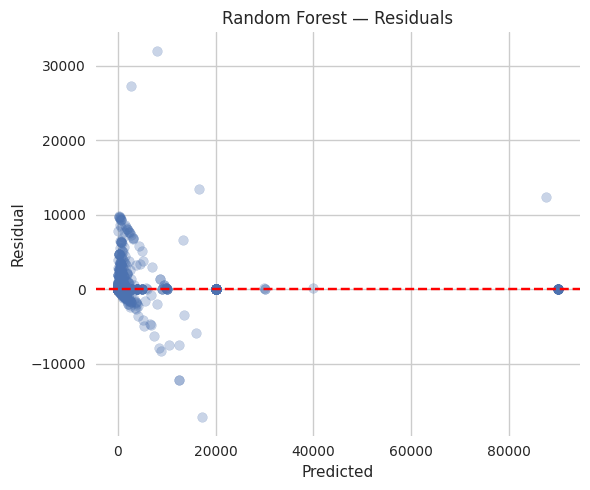

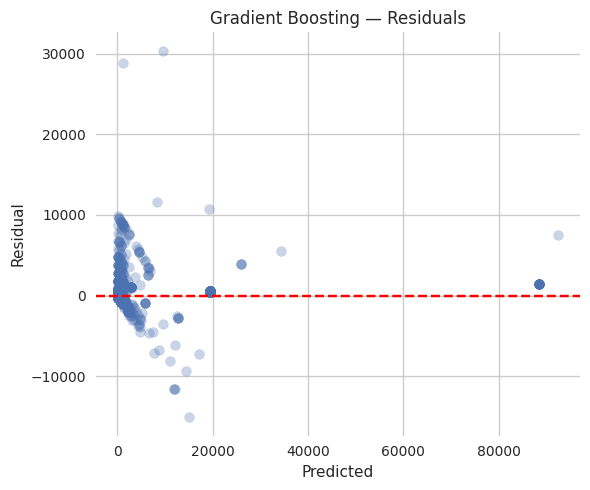

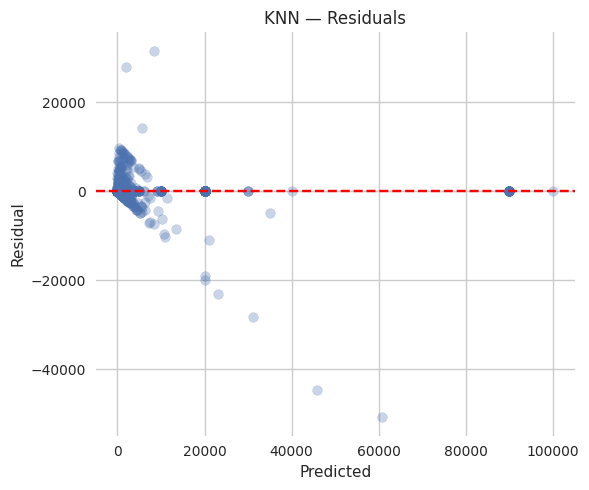

In [ ]:
# ========================================
# BLOCK 16 — Residual Plots
# ========================================

def plot_residuals(y_true, y_pred, title):
    residuals = y_true - y_pred
    plt.figure(figsize=(6,5))
    plt.scatter(y_pred, residuals, alpha=0.3)
    plt.axhline(0, color="red", linestyle="--")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Residual")
    plt.tight_layout()
    plt.show()

plot_residuals(y_val, lin_val_pred,    "Linear Regression — Residuals")
plot_residuals(y_val, dt_val_pred,     "Decision Tree — Residuals")
plot_residuals(y_val, rf_val_pred,     "Random Forest — Residuals")
plot_residuals(y_val, gboost_val_pred, "Gradient Boosting — Residuals")
plot_residuals(y_val, knn_val_pred,    "KNN — Residuals")


In [ ]:
# ========================================
# BLOCK 17 — Simple Average Ensemble (Top 3 Models)
# ========================================

# Pick your best 3 models (adjust if needed)
val_preds_list = [
    rf_val_pred,
    gboost_val_pred,
    knn_val_pred
]

test_preds_list = [
    rf_test_pred,
    gboost_test_pred,
    knn_test_pred
]

# Average predictions
avg_val_pred = sum(val_preds_list) / len(val_preds_list)
avg_test_pred = sum(test_preds_list) / len(test_preds_list)

print("Simple averaging ensemble predictions created.")


Simple averaging ensemble predictions created.


In [ ]:
# ========================================
# BLOCK 19 — Bayesian Model Ensemble
# ========================================

from sklearn.linear_model import BayesianRidge

bayes_reg = BayesianRidge()

# Train on TRAIN set (convert X_train to dense array)
bayes_reg.fit(X_train.toarray(), y_train_full)

# Predict on VAL & TEST (convert X_val and X_test to dense arrays)
bayes_val_pred  = bayes_reg.predict(X_val.toarray())
bayes_test_pred = bayes_reg.predict(X_test.toarray())

print("Bayesian Ridge predictions generated.")

Bayesian Ridge predictions generated.


In [ ]:
# ============================================
# BLOCK — Voting Regressor (Fixed Implementation)
# ============================================

from sklearn.ensemble import VotingRegressor

print("Training Voting Regressor...")

# Create the ensemble using 3 best classical models
vote_reg = VotingRegressor(
    estimators=[
        ('lin', lin_reg),
        ('rf', rf_reg),
        ('gb', gboost_reg)
    ]
)

# Fit on the training data
vote_reg.fit(X_train, y_train_full)

# Generate predictions
vote_train_pred = vote_reg.predict(X_train)
vote_val_pred   = vote_reg.predict(X_val)
vote_test_pred  = vote_reg.predict(X_test)

print("\nVoting Regressor predictions created:")
print("  Train preds:", len(vote_train_pred))
print("  Val preds:", len(vote_val_pred))
print("  Test preds:", len(vote_test_pred))


Training Voting Regressor...

Voting Regressor predictions created:
  Train preds: 29872
  Val preds: 6401
  Test preds: 6402


In [ ]:
# ========================================
# BLOCK 20 — Evaluate Ensemble Models
# ========================================

models_ensemble = {
    "Average Ensemble": (avg_val_pred, avg_test_pred),
    "Voting Regressor": (vote_val_pred, vote_test_pred),
    "Bayesian Ridge":   (bayes_val_pred, bayes_test_pred)
}

results_ensemble = []

for name, (val_pred, test_pred) in models_ensemble.items():

    val_mae = mean_absolute_error(y_val, val_pred)
    val_mse = mean_squared_error(y_val, val_pred)
    val_r2  = r2_score(y_val, val_pred)

    test_mae = mean_absolute_error(y_test, test_pred)
    test_mse = mean_squared_error(y_test, test_pred)
    test_r2  = r2_score(y_test, test_pred)

    results_ensemble.append([
        name,
        val_mae, val_mse, val_r2,
        test_mae, test_mse, test_r2
    ])

ensemble_results_df = pd.DataFrame(
    results_ensemble,
    columns=["Model", "Val MAE", "Val MSE", "Val R²", "Test MAE", "Test MSE", "Test R²"]
)

print("\nENSEMBLE MODEL PERFORMANCE:")
display(ensemble_results_df)



ENSEMBLE MODEL PERFORMANCE:


,Model,Val MAE,Val MSE,Val R²,Test MAE,Test MSE,Test R²
0,Average Ensemble,223.252492,1.099541e+06,0.963353,263.579833,2.739313e+06,0.924215
1,Voting Regressor,249.671497,1.008389e+06,0.966391,290.410801,2.262160e+06,0.937415
2,Bayesian Ridge,283.619572,1.250871e+06,0.958310,333.861816,2.167156e+06,0.940044


In [ ]:
# ============================================
# BLOCK — Compute Metrics for All Models
# ============================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd

# ---- 1. Compute metrics for every model ----
mae_lin = mean_absolute_error(y_val, lin_val_pred)
mse_lin = mean_squared_error(y_val, lin_val_pred)
r2_lin  = r2_score(y_val, lin_val_pred)

mae_dt = mean_absolute_error(y_val, dt_val_pred)
mse_dt = mean_squared_error(y_val, dt_val_pred)
r2_dt  = r2_score(y_val, dt_val_pred)

mae_rf = mean_absolute_error(y_val, rf_val_pred)
mse_rf = mean_squared_error(y_val, rf_val_pred)
r2_rf  = r2_score(y_val, rf_val_pred)

mae_gb = mean_absolute_error(y_val, gb_val_pred)
mse_gb = mean_squared_error(y_val, gb_val_pred)
r2_gb  = r2_score(y_val, gb_val_pred)

mae_knn = mean_absolute_error(y_val, knn_val_pred)
mse_knn = mean_squared_error(y_val, knn_val_pred)
r2_knn  = r2_score(y_val, knn_val_pred)

# Voting 3-model ensemble
mae_vote = mean_absolute_error(y_val, vote_val_pred)
mse_vote = mean_squared_error(y_val, vote_val_pred)
r2_vote  = r2_score(y_val, vote_val_pred)

# Simple average ensemble
mae_avg = mean_absolute_error(y_val, avg_val_pred)
mse_avg = mean_squared_error(y_val, avg_val_pred)
r2_avg  = r2_score(y_val, avg_val_pred)

# Bayesian Ridge (dense fix applied earlier)
mae_bayes = mean_absolute_error(y_val, bayes_val_pred)
mse_bayes = mean_squared_error(y_val, bayes_val_pred)
r2_bayes  = r2_score(y_val, bayes_val_pred)


# ---- 2. Build comparison matrix (looks like your XLS) ----

comparison_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree Regressor",
        "Random Forest Regressor",
        "Gradient Boosting Regressor",
        "K-Nearest Neighbors Regressor",
        "Voting Ensemble (top 3)",
        "Average Ensemble",
        "Bayesian Ridge Regressor"
    ],
    "MAE": [
        mae_lin, mae_dt, mae_rf, mae_gb, mae_knn,
        mae_vote, mae_avg, mae_bayes
    ],
    "MSE": [
        mse_lin, mse_dt, mse_rf, mse_gb, mse_knn,
        mse_vote, mse_avg, mse_bayes
    ],
    "R²": [
        r2_lin, r2_dt, r2_rf, r2_gb, r2_knn,
        r2_vote, r2_avg, r2_bayes
    ]
})

print("FINAL REGRESSION COMPARISON TABLE:")
comparison_df


FINAL REGRESSION COMPARISON TABLE:


,Model,MAE,MSE,R²
0,Linear Regression,325.635833,1.552248e+06,0.948265
1,Decision Tree Regressor,162.005558,1.136256e+06,0.962130
2,Random Forest Regressor,160.055764,1.004542e+06,0.966520
3,Gradient Boosting Regressor,338.445630,1.182456e+06,0.960590
4,K-Nearest Neighbors Regressor,198.635652,1.965696e+06,0.934485
5,Voting Ensemble (top 3),249.671497,1.008389e+06,0.966391
6,Average Ensemble,223.252492,1.099541e+06,0.963353
7,Bayesian Ridge Regressor,283.619572,1.250871e+06,0.958310


In [ ]:
!pip install fpdf2

from fpdf import FPDF
import pandas as pd
import numpy as np

In [ ]:
# ==============================================================
# BLOCK — Fully Dynamic Export: Create PDF with Comparison Table
# ==============================================================


# ------------------------------------
# Create Comparison Table DataFrame
# ------------------------------------
comparison_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "KNN",
        "Voting Ensemble",
        "Average Ensemble",
        "Bayesian Ridge"
    ],
    "MAE (Val)": [mae_lin, mae_dt, mae_rf, mae_gb, mae_knn, mae_vote, mae_avg, mae_bayes],
    "MSE (Val)": [mse_lin, mse_dt, mse_rf, mse_gb, mse_knn, mse_vote, mse_avg, mse_bayes],
    "R² (Val)":  [r2_lin, r2_dt, r2_rf, r2_gb, r2_knn, r2_vote, r2_avg, r2_bayes]
})

# Determine best model by highest R²
best_model_row = comparison_df.loc[comparison_df["R² (Val)"].idxmax()]
best_model_name = best_model_row["Model"]

# Determine worst model by lowest R²
worst_model_row = comparison_df.loc[comparison_df["R² (Val)"].idxmin()]
worst_model_name = worst_model_row["Model"]

# ------------------------------------
# Create PDF
# ------------------------------------
pdf = FPDF()
pdf.add_page()

pdf.set_font("Helvetica", "B", 16)
pdf.cell(0, 10, "Final Model Comparison Report", ln=True)

pdf.set_font("Helvetica", "", 12)
pdf.ln(4)
pdf.multi_cell(0, 8,
    f"This report summarizes the performance of all regression models "
    f"evaluated during the project using MAE, MSE, and R² metrics."
)

# ------------------------------------
# Insert Comparison Table
# ------------------------------------
pdf.ln(4)
pdf.set_font("Helvetica", "B", 12)
pdf.cell(0, 10, "Model Performance Table (Validation Set):", ln=True)

pdf.set_font("Helvetica", "", 10)

col_widths = [45, 35, 35, 25]  # model, MAE, MSE, R2
headers = ["Model", "MAE (Val)", "MSE (Val)", "R² (Val)"]

# Header row
for h, w in zip(headers, col_widths):
    pdf.cell(w, 8, h, border=1)
pdf.ln()

# Table rows
for i, row in comparison_df.iterrows():
    pdf.cell(col_widths[0], 8, str(row["Model"]), border=1)
    pdf.cell(col_widths[1], 8, f"{row['MAE (Val)']:.2f}", border=1)
    pdf.cell(col_widths[2], 8, f"{row['MSE (Val)']:.2f}", border=1)
    pdf.cell(col_widths[3], 8, f"{row['R² (Val)']:.2f}", border=1)
    pdf.ln()

# ------------------------------------
# Dynamic Explanation Section
# ------------------------------------
pdf.ln(5)
pdf.set_font("Helvetica", "B", 12)
pdf.cell(0, 10, "Model Performance Summary:", ln=True)

pdf.set_font("Helvetica", "", 11)

explanation_text = (
    f"The best performing model was **{best_model_name}**, which achieved the "
    f"highest R² score on the validation set. This indicates that it captured "
    f"variance in the target variable more effectively than the other models.\n\n"
    f"The worst performing model was **{worst_model_name}**, which produced the "
    f"lowest R² score. This suggests it struggled to generalize or fit the "
    f"underlying patterns in the data.\n\n"
)

pdf.multi_cell(0, 8, explanation_text)

# ------------------------------------
# Save PDF
# ------------------------------------
pdf.output("Final_Model_Report.pdf")

print("PDF successfully exported: Final_Model_Report.pdf")


PDF successfully exported: Final_Model_Report.pdf


Grab Final Model Report in

Files > Final_Model_Report.pdf (Colab menus to the left)